# 📊 EDA — ViSmish SMS Dataset

Notebook này thực hiện phân tích EDA toàn diện trên bộ dữ liệu phát hiện tin nhắn lừa đảo SMS tiếng Việt **ViSmish**..

| Thuộc tính | Giá trị |
|-----------|-------|
| Số hàng | 10 562 |
| Số cột | 9 |
| Mục đích | Phân loại nhị phân (label 0 = ham, 1 = scam) |
| Ngôn ngữ | Tiếng Việt |

**Các phần**
1. Cài đặt & Tải dữ liệu  
2. Tổng quan  
3. Phân phối nhãn mục tiêu  
4. Phân tích từng đặc trưng  
5. Phân tích văn bản  
6. Tương quan & Bảng chéo  
7. Kết quả chính


## 1. Cài đặt & Tải dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

# ── Style ──────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
SCAM_COLOR  = "#E84B3A"
HAM_COLOR   = "#2E86AB"
PALETTE     = [HAM_COLOR, SCAM_COLOR]

# ── Load ───────────────────────────────────────────────────────────────────────
df = pd.read_csv("temp.csv")
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Dataset loaded: 10,562 rows × 9 columns


,sample_id,content,label,has_url,has_phone_number,sender_type,category,obfuscation_level,data_origin
0,ViSmish_00000,(TB) SINH NHẬT VINA - NẠP THẺ CÓ QUÀ! VinaPhon...,0,1,1,brandname,Viễn thông,NONE,real
1,ViSmish_00001,Quy khach duoc cong them 8 diem Viettel++ boi ...,0,1,0,brandname,Khác,NONE,real
2,ViSmish_00002,Cuc Thue: Nguyen Thi Xuan can bo sung giay to ...,1,0,0,brandname,Dịch vụ công,Level 2 - Leet nặng,synthetic_hard_positive
3,ViSmish_00003,Dịch vụ Quản lý Danh tính Quốc gia: Tài khoản ...,1,1,0,personal_number,Dịch vụ công,Level 0 - Formal,paraphrased
4,ViSmish_00004,[VPBank] Tài khoản ngưng hoạt động đột ngột. T...,1,1,0,brandname,Ngân hàng,Level 0 - Formal,paraphrased


## 2. Tổng quan

In [2]:
print("=" * 55)
print("SCHEMA")
print("=" * 55)
df.info()


SCHEMA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10562 entries, 0 to 10561
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   sample_id          10562 non-null  object
 1   content            10562 non-null  object
 2   label              10562 non-null  int64 
 3   has_url            10562 non-null  int64 
 4   has_phone_number   10562 non-null  int64 
 5   sender_type        10562 non-null  object
 6   category           10562 non-null  object
 7   obfuscation_level  10562 non-null  object
 8   data_origin        10562 non-null  object
dtypes: int64(3), object(6)
memory usage: 742.8+ KB


In [3]:
print("=" * 55)
print("MISSING VALUES")
print("=" * 55)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"Missing #": missing, "Missing %": missing_pct})


MISSING VALUES


,Missing #,Missing %
sample_id,0,0.0
content,0,0.0
label,0,0.0
has_url,0,0.0
has_phone_number,0,0.0
sender_type,0,0.0
category,0,0.0
obfuscation_level,0,0.0
data_origin,0,0.0


In [4]:
print("=" * 55)
print("NUMERIC SUMMARY")
print("=" * 55)
df.describe().T


NUMERIC SUMMARY


,count,mean,std,min,25%,50%,75%,max
label,10562.0,0.496308,0.500010,0.0,0.0,0.0,1.0,1.0
has_url,10562.0,0.471028,0.499184,0.0,0.0,0.0,1.0,1.0
has_phone_number,10562.0,0.275611,0.446843,0.0,0.0,0.0,1.0,1.0


In [5]:
print("=" * 55)
print("DUPLICATE ROWS")
print("=" * 55)
n_dup = df.duplicated().sum()
print(f"Duplicate rows: {n_dup}  ({n_dup/len(df)*100:.2f}%)")


DUPLICATE ROWS
Duplicate rows: 0  (0.00%)


### 🔍 Nhận xét — Tổng quan dữ liệu

Bộ dữ liệu **ViSmish** bao gồm **10.562 mẫu tin nhắn SMS** với **9 đặc trưng**, không có giá trị thiếu ở bất kỳ cột nào — đây là điểm đáng chú ý vì phần lớn dữ liệu thực tế thường có dữ liệu thiếu, và không có hàng trùng lặp.

**Ý nghĩa từng đặc trưng:**

| Đặc trưng | Kiểu | Vai trò |
|-----------|------|---------|
| `sample_id` | str | Định danh duy nhất — không dùng cho mô hình |
| `content` | str | Nội dung tin nhắn — **đặc trưng quan trọng nhất** |
| `label` | int (0/1) | Nhãn phân loại — biến mục tiêu |
| `has_url` | int (0/1) | Có chứa URL hay không |
| `has_phone_number` | int (0/1) | Có chứa số điện thoại hay không |
| `sender_type` | str | Loại người gửi (brandname / personal_number / shortcode) |
| `category` | str | Danh mục nội dung tin nhắn (19 loại) |
| `obfuscation_level` | str | Mức độ che giấu văn bản (7 mức) |
| `data_origin` | str | Nguồn gốc dữ liệu (real / synthetic / paraphrased...) |

**Chất lượng dữ liệu:** Dữ liệu sạch — không missing, không duplicate. Sẵn sàng cho mô hình hóa mà không cần bước xử lý dữ liệu thiếu.

## 3. Phân phối nhãn mục tiêu
`label`: 0 = Ham (legitimate), 1 = Smishing

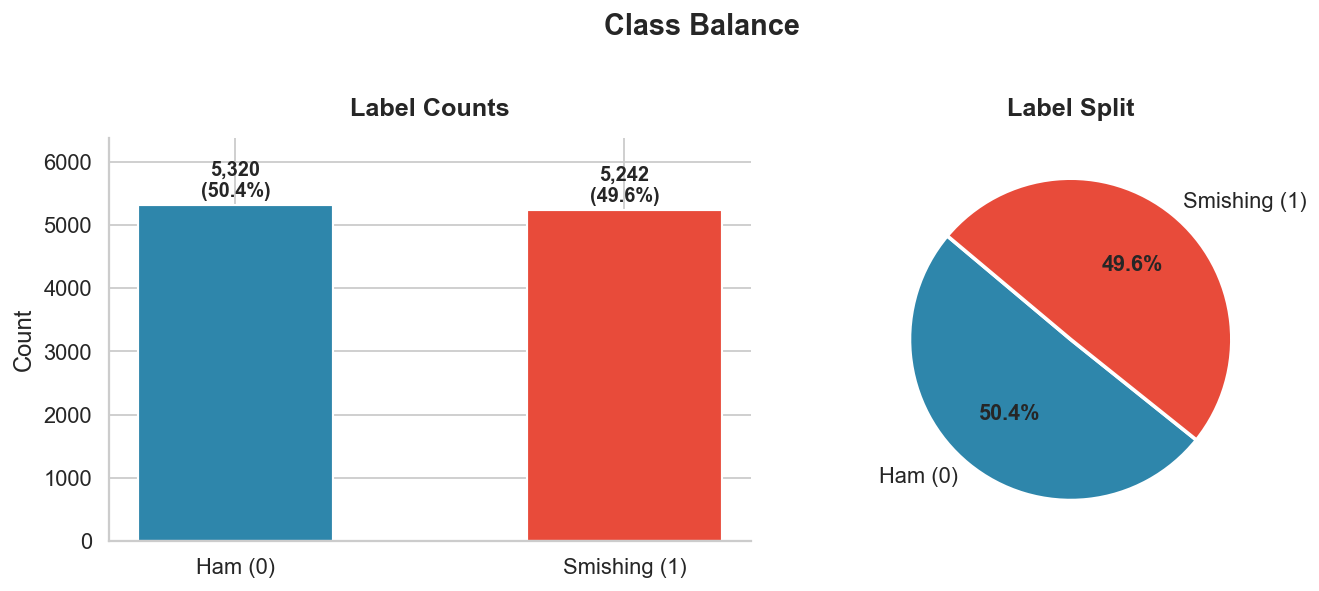


Class balance ratio (ham:scam) ≈ 1.01:1  →  Nearly balanced dataset


In [6]:
counts = df["label"].value_counts().sort_index()
labels_txt = ["Ham (0)", "Smishing (1)"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Bar chart
bars = axes[0].bar(labels_txt, counts.values, color=PALETTE, width=0.5, edgecolor="white", linewidth=1.2)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
                 f"{val:,}\n({val/len(df)*100:.1f}%)",
                 ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[0].set_title("Label Counts", fontsize=14, fontweight="bold", pad=12)
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, counts.max() * 1.2)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=labels_txt, autopct="%1.1f%%",
    colors=PALETTE, startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=2)
)
for t in autotexts:
    t.set_fontsize(12); t.set_fontweight("bold")
axes[1].set_title("Label Split", fontsize=14, fontweight="bold", pad=12)

plt.suptitle("Class Balance", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"\nClass balance ratio (ham:scam) ≈ {counts[0]/counts[1]:.2f}:1  →  Nearly balanced dataset")


### 🔍 Nhận xét — Phân phối nhãn mục tiêu

| Nhãn | Số lượng | Tỷ lệ |
|------|----------|-------|
| Ham (0) — Tin nhắn hợp lệ | 5.320 | **50,4%** |
| Smishing (1) — Tin nhắn lừa đảo | 5.242 | **49,6%** |

Bộ dữ liệu có **tỷ lệ nhãn gần như hoàn toàn cân bằng**, với chênh lệch chỉ 78 mẫu (~0,7%). Đây là thiết kế có chủ đích.

**Ý nghĩa thực tiễn:**
- Không cần các kỹ thuật xử lý mất cân bằng như SMOTE, class weighting, hay oversampling/undersampling.
- **Accuracy** vẫn là metric có ý nghĩa (không bị misleading như trong bài toán mất cân bằng nặng).
- Nên bổ sung **F1-score, Precision, Recall** vì chi phí nhầm scam thành ham (False Negative) cao hơn nhầm ham thành scam (False Positive) trong thực tế.

## 4. Phân tích các đặc trưng

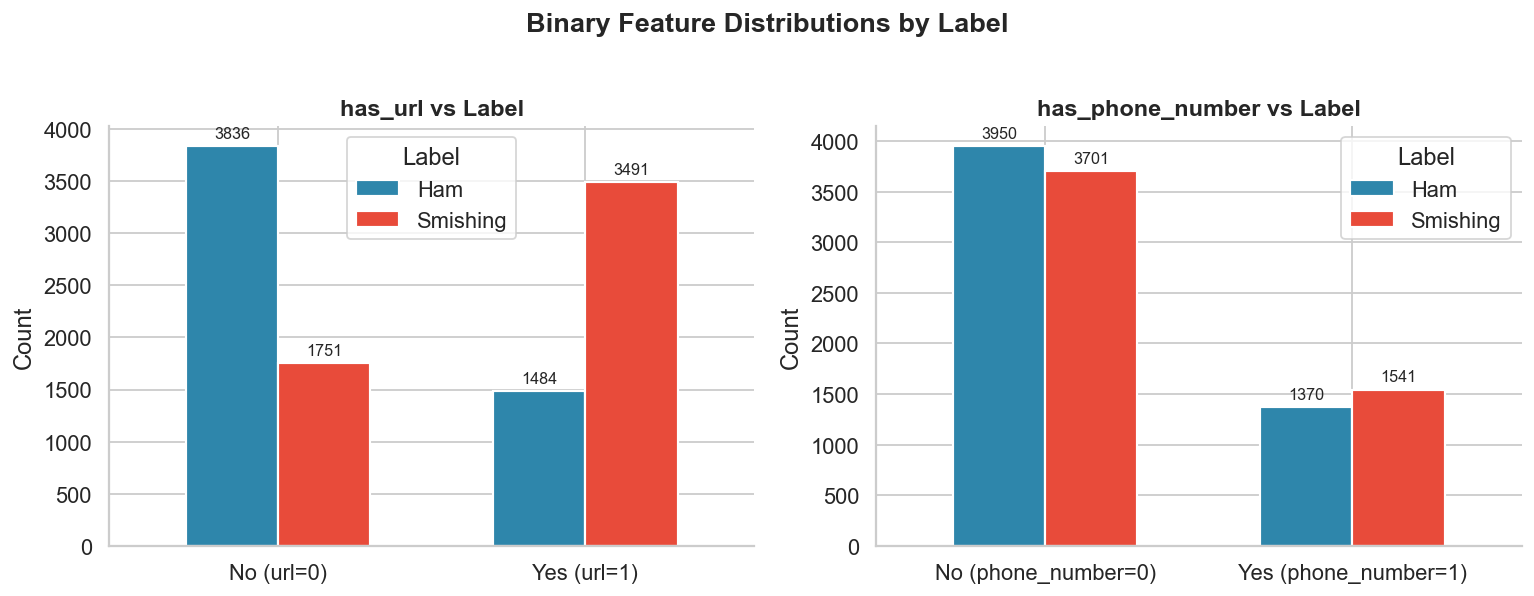

In [7]:
# ── Binary features: has_url & has_phone_number ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
bin_features = ["has_url", "has_phone_number"]

for ax, feat in zip(axes, bin_features):
    ct = df.groupby([feat, "label"]).size().unstack(fill_value=0)
    ct.index = [f"No ({feat.replace('has_', '')}=0)", f"Yes ({feat.replace('has_', '')}=1)"]
    ct.columns = ["Ham", "Smishing"]
    ct.plot(kind="bar", ax=ax, color=PALETTE, edgecolor="white", linewidth=1.2, rot=0, width=0.6)
    ax.set_title(f"{feat} vs Label", fontsize=13, fontweight="bold")
    ax.set_ylabel("Count")
    ax.legend(title="Label")
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", padding=3, fontsize=9)

plt.suptitle("Binary Feature Distributions by Label", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### 🔍 Nhận xét — Đặc trưng nhị phân: `has_url` & `has_phone_number`

**`has_url` — Tín hiệu phân biệt mạnh:**

| Nhãn | Không có URL | Có URL |
|------|-------------|--------|
| Ham  | 72,1% | 27,9% |
| Smishing | 33,4% | **66,6%** |

Tin nhắn scam chứa URL với tỷ lệ **66,6%** — gấp hơn 2,4 lần so với ham (27,9%). Đây là đặc trưng phân biệt **mạnh nhất** trong nhóm đặc trưng số, với hệ số tương quan Pearson với `label` đạt **0,39**. Chiến thuật này phản ánh thực tế: kẻ tấn công thường dẫn dụ người dùng click vào link giả để thu thập thông tin hoặc cài mã độc.

**`has_phone_number` — Tín hiệu yếu:**

| Nhãn | Không có SĐT | Có SĐT |
|------|-------------|--------|
| Ham  | 74,2% | 25,8% |
| Smishing | 70,6% | 29,4% |

Số điện thoại xuất hiện ở cả hai nhóm với tỷ lệ tương đương — chênh lệch chỉ **3,6 điểm phần trăm**, tương quan Pearson với `label` chỉ **0,04**. Đặc trưng này có giá trị phân biệt thấp khi đứng độc lập, nhưng có thể hữu ích khi kết hợp với các đặc trưng khác (ví dụ: `sender_type = personal_number` + `has_phone_number = 1`).

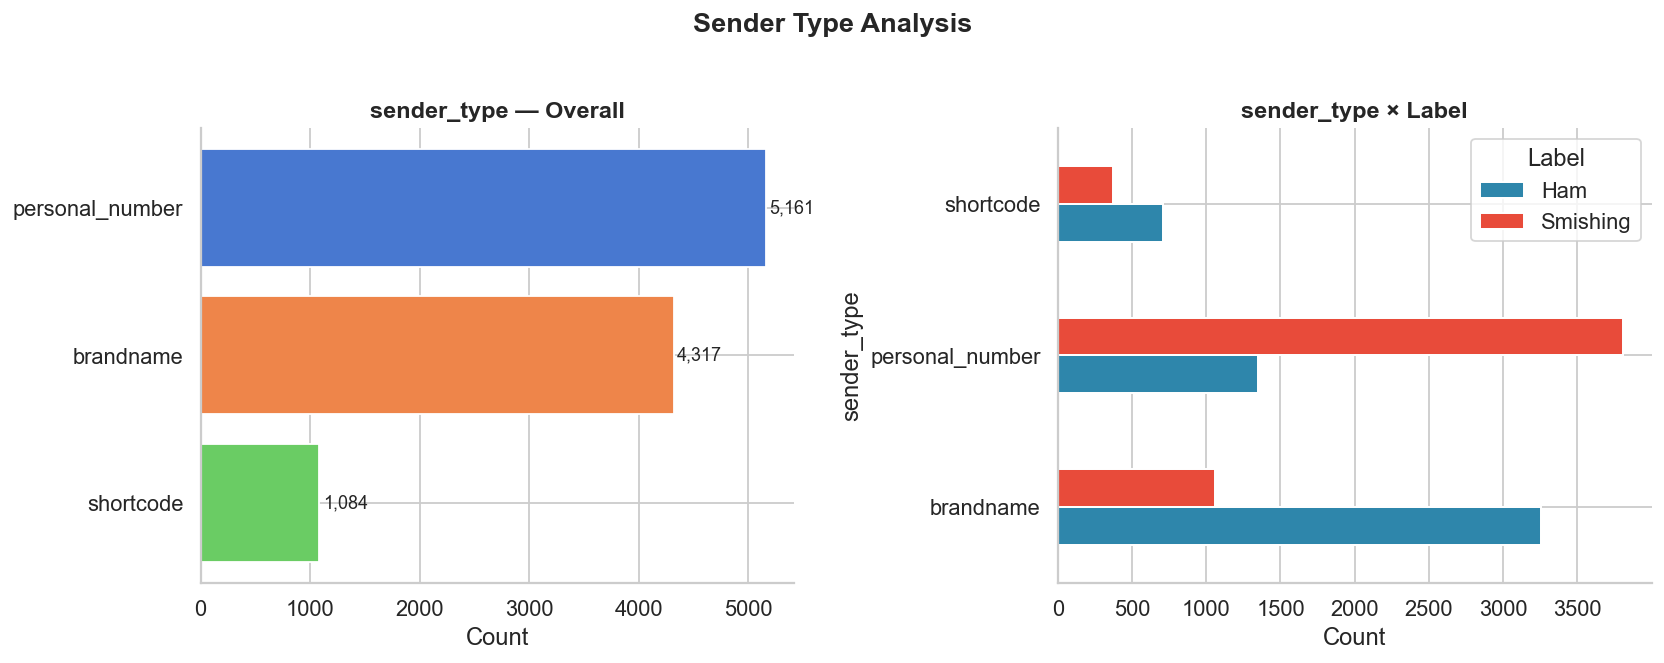

In [8]:
# ── sender_type ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Overall
vc = df["sender_type"].value_counts()
axes[0].barh(vc.index, vc.values, color=sns.color_palette("muted", len(vc)), edgecolor="white")
for i, v in enumerate(vc.values):
    axes[0].text(v + 30, i, f"{v:,}", va="center", fontsize=10)
axes[0].set_title("sender_type — Overall", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Count")
axes[0].invert_yaxis()

# By label
ct = df.groupby(["sender_type", "label"]).size().unstack(fill_value=0)
ct.columns = ["Ham", "Smishing"]
ct.plot(kind="barh", ax=axes[1], color=PALETTE, edgecolor="white", linewidth=1.1)
axes[1].set_title("sender_type × Label", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Count")
axes[1].legend(title="Label")

plt.suptitle("Sender Type Analysis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### 🔍 Nhận xét — Loại người gửi (`sender_type`)

| Loại người gửi | Tổng số | Ham % | Smishing % |
|----------------|---------|-------|--------|
| `personal_number` (số cá nhân) | 5.161 | 26,2% | **73,8%** |
| `brandname` (tên thương hiệu) | 4.317 | **75,4%** | 24,6% |
| `shortcode` (đầu số ngắn) | 1.084 | **65,7%** | 34,3% |

**Phân tích chi tiết:**

- **`personal_number`** chiếm gần nửa bộ dữ liệu (48,9%) và nghiêng **mạnh về scam (73,8%)**. Tổ chức hợp lệ không nhắn tin từ số điện thoại cá nhân — đây là dấu hiệu đáng ngờ rõ ràng.
- **`brandname`** đa phần là ham (75,4%), nhưng tỷ lệ scam vẫn đáng kể (24,6%) — cho thấy kẻ tấn công giả mạo tên thương hiệu để tạo lòng tin.
- **`shortcode`** cũng thiên về ham (65,7%) nhưng có tỷ lệ scam 34,3% — shortcode giả có thể bị dùng cho lừa đảo.

**Kết luận:** `sender_type` là đặc trưng phân loại có giá trị cao, nên đưa vào mô hình dưới dạng **one-hot encoding** hoặc **target encoding**.

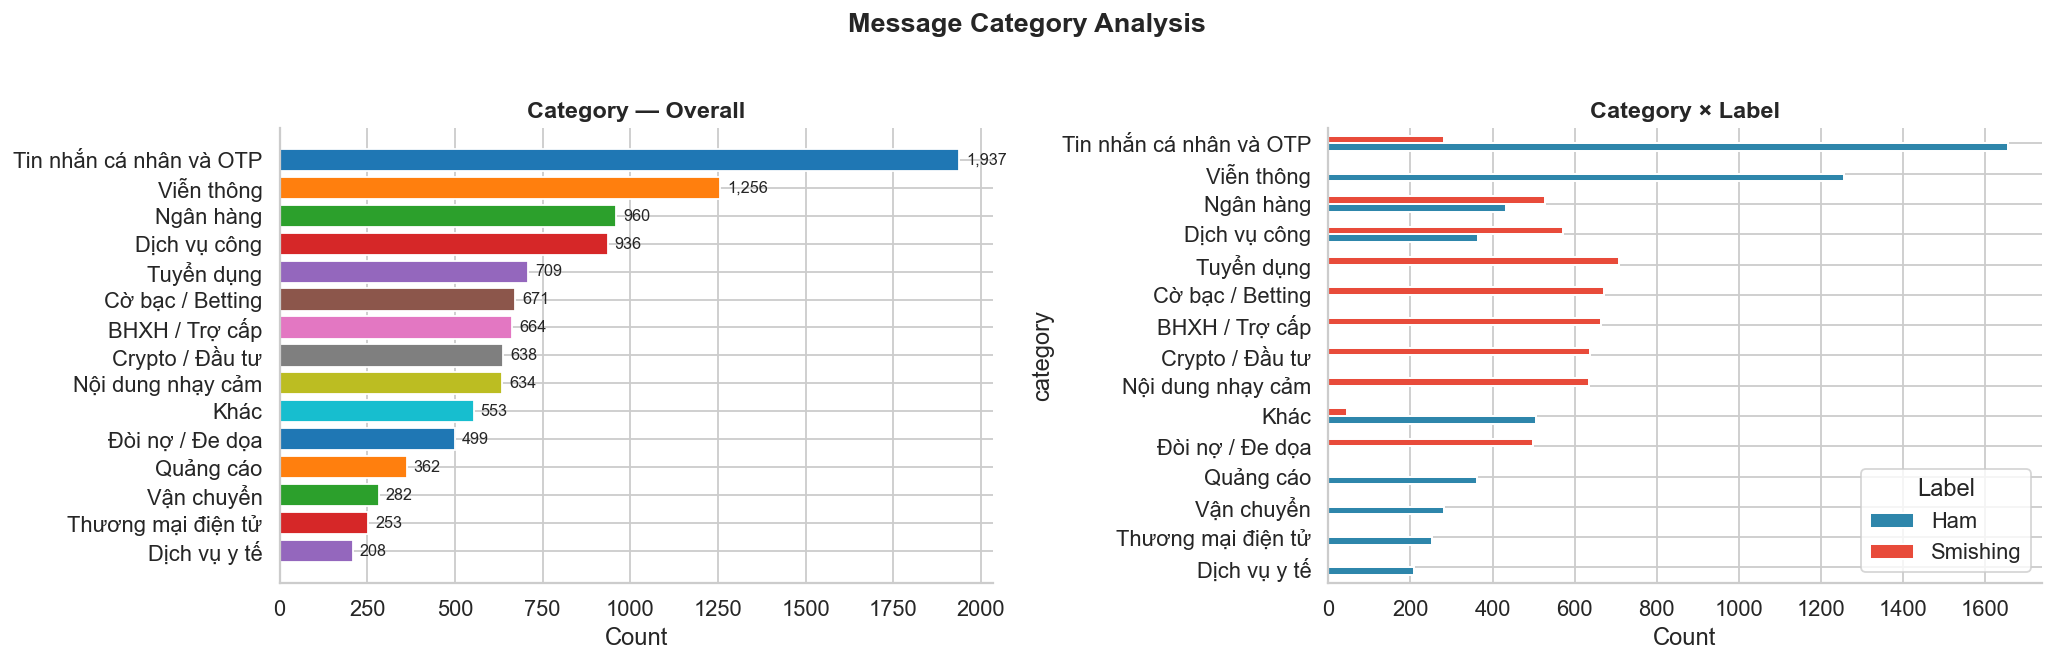

In [9]:
# ── category ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

vc = df["category"].value_counts()
colors = sns.color_palette("tab10", len(vc))
axes[0].barh(vc.index, vc.values, color=colors, edgecolor="white")
for i, v in enumerate(vc.values):
    axes[0].text(v + 20, i, f"{v:,}", va="center", fontsize=9)
axes[0].set_title("Category — Overall", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Count")
axes[0].invert_yaxis()

ct = df.groupby(["category", "label"]).size().unstack(fill_value=0)
ct.columns = ["Ham", "Smishing"]
ct_sorted = ct.sum(axis=1).sort_values().index
ct.loc[ct_sorted].plot(kind="barh", ax=axes[1], color=PALETTE, edgecolor="white", linewidth=1.1)
axes[1].set_title("Category × Label", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Count")
axes[1].legend(title="Label")

plt.suptitle("Message Category Analysis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


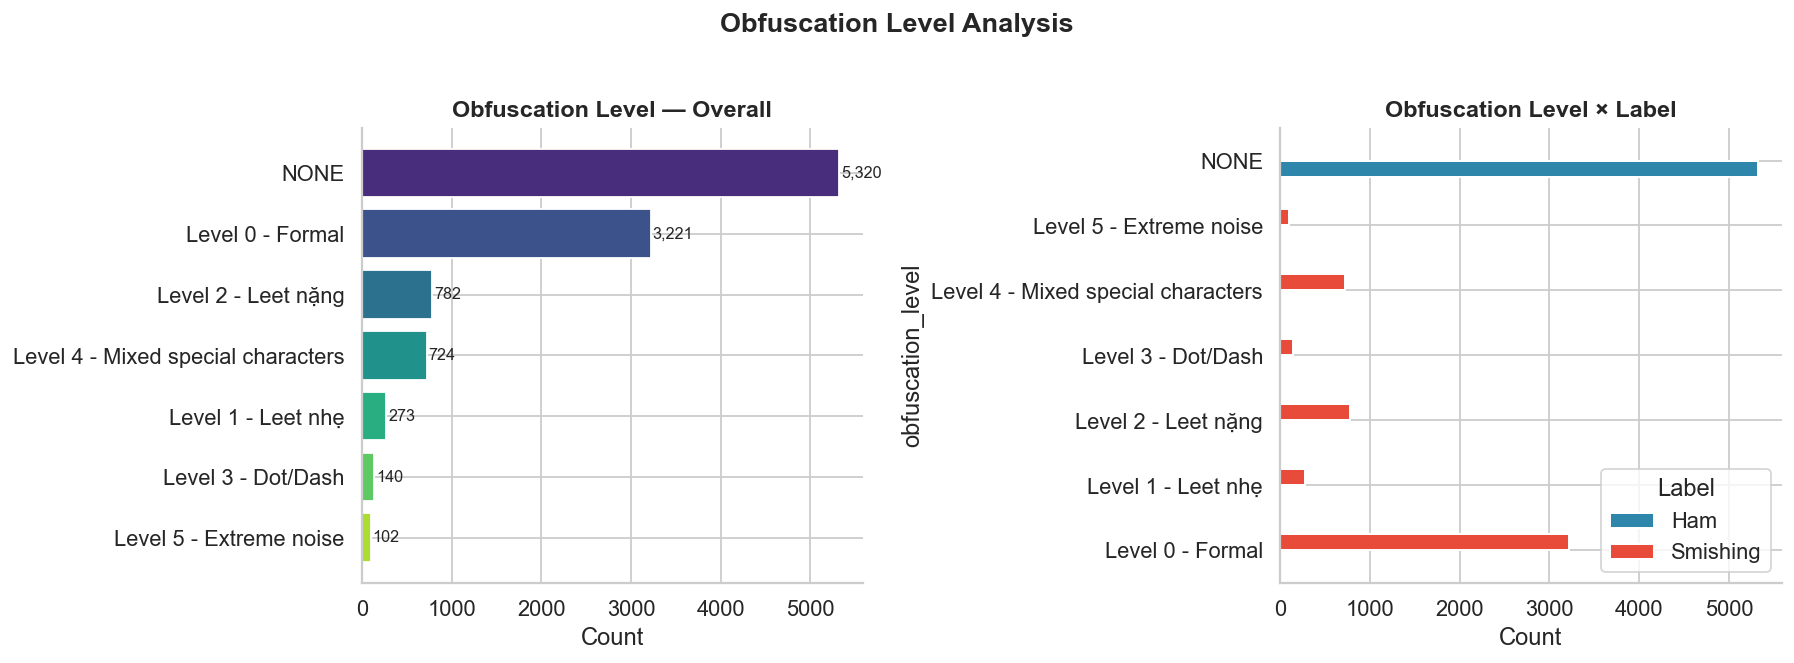

In [10]:
# ── obfuscation_level ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vc = df["obfuscation_level"].value_counts()
axes[0].barh(vc.index, vc.values, color=sns.color_palette("viridis", len(vc)), edgecolor="white")
for i, v in enumerate(vc.values):
    axes[0].text(v + 20, i, f"{v:,}", va="center", fontsize=9)
axes[0].set_title("Obfuscation Level — Overall", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Count")
axes[0].invert_yaxis()

ct = df.groupby(["obfuscation_level", "label"]).size().unstack(fill_value=0)
ct.columns = ["Ham", "Smishing"]
ct.plot(kind="barh", ax=axes[1], color=PALETTE, edgecolor="white", linewidth=1.1)
axes[1].set_title("Obfuscation Level × Label", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Count")
axes[1].legend(title="Label")

plt.suptitle("Obfuscation Level Analysis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### 🔍 Nhận xét — Mức độ che giấu văn bản (`obfuscation_level`)

| Mức độ | Số lượng | Tỷ lệ | Nhãn |
|--------|----------|-------|------|
| `NONE` (không che giấu) | 5.320 | 50,4% | **100% Ham** |
| `Level 0 - Formal` (định dạng chuẩn) | 3.221 | 30,5% | **100% Smishing** |
| `Level 2 - Leet nặng` | 782 | 7,4% | 100% Smishing |
| `Level 4 - Mixed special characters` | 724 | 6,9% | 100% Smishing |
| `Level 1 - Leet nhẹ` | 273 | 2,6% | 100% Smishing |
| `Level 3 - Dot/Dash` | 140 | 1,3% | 100% Smishing |
| `Level 5 - Extreme noise` | 102 | 1,0% | 100% Smishing |

**Phát hiện quan trọng:** Tất cả tin nhắn ham đều có `NONE` (không bị che giấu), trong khi **toàn bộ tin nhắn scam** có ít nhất Level 0. Điều này phản ánh thực tế: kẻ tấn công cố tình biến đổi văn bản (thay ký tự, thêm dấu, dùng leet speak) để qua mặt bộ lọc từ khóa.

Phần lớn scam dùng Level 0 (văn phong trang trọng, không obfuscate) — cho thấy nhiều kẻ tấn công vẫn chưa cần dùng kỹ thuật che giấu phức tạp để lừa được người dùng.

> ⚠️ **Lưu ý:** Tương tự `category`, đặc trưng này cũng hoàn toàn tách biệt hai nhãn — sử dụng trực tiếp sẽ gây **data leakage**. Trong thực tế, mức độ obfuscation cần được suy ra từ nội dung.

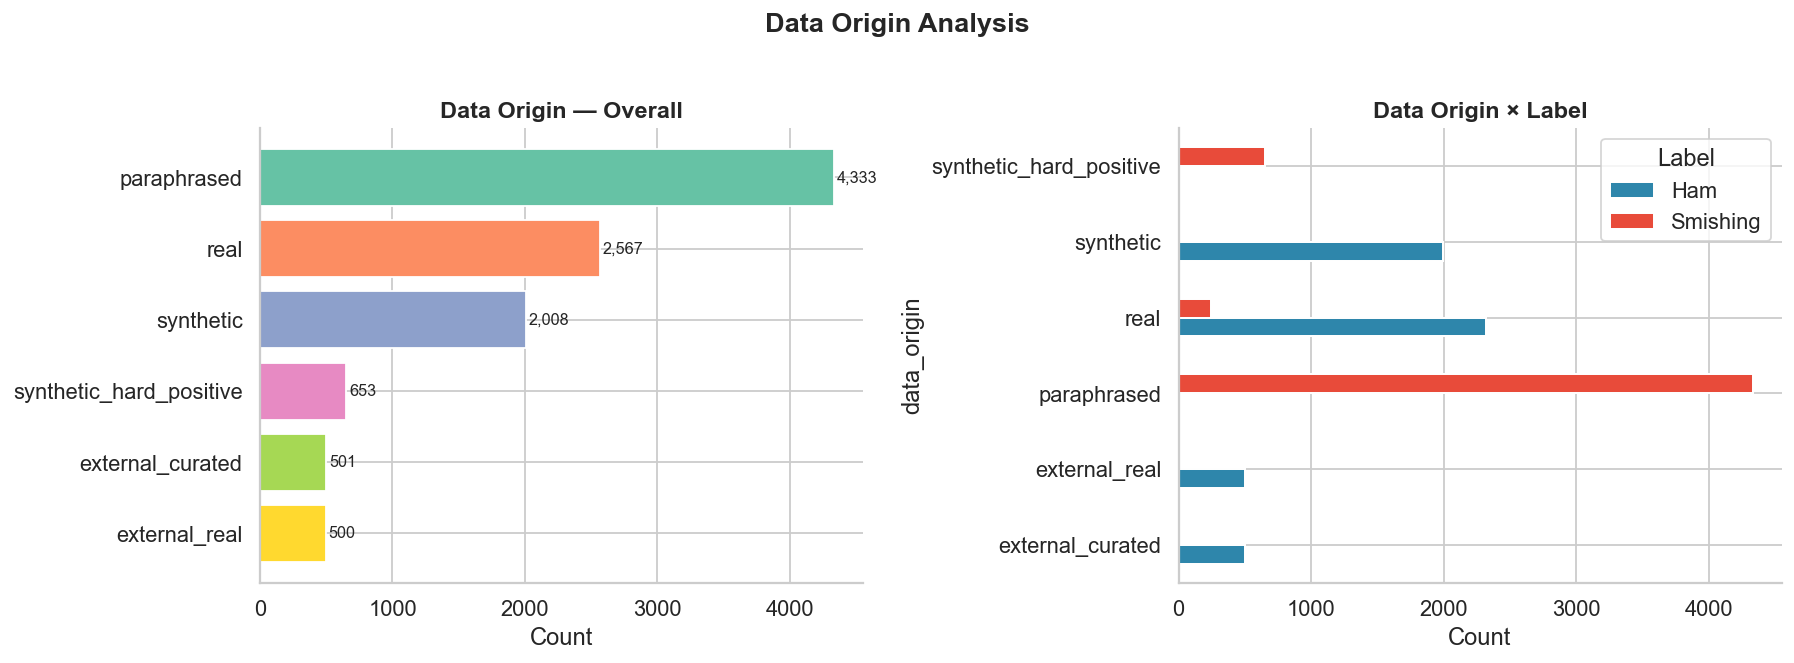

In [11]:
# ── data_origin ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vc = df["data_origin"].value_counts()
axes[0].barh(vc.index, vc.values, color=sns.color_palette("Set2", len(vc)), edgecolor="white")
for i, v in enumerate(vc.values):
    axes[0].text(v + 20, i, f"{v:,}", va="center", fontsize=9)
axes[0].set_title("Data Origin — Overall", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Count")
axes[0].invert_yaxis()

ct = df.groupby(["data_origin", "label"]).size().unstack(fill_value=0)
ct.columns = ["Ham", "Smishing"]
ct.plot(kind="barh", ax=axes[1], color=PALETTE, edgecolor="white", linewidth=1.1)
axes[1].set_title("Data Origin × Label", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Count")
axes[1].legend(title="Label")

plt.suptitle("Data Origin Analysis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### 🔍 Nhận xét — Nguồn gốc dữ liệu (`data_origin`)

| Nguồn | Số lượng | Tỷ lệ | Ham % | Smishing % |
|-------|----------|-------|-------|--------|
| `paraphrased` | 4.333 | 41,0% | 0% | **100%** |
| `real` | 2.567 | 24,3% | **90,4%** | 9,6% |
| `synthetic` | 2.008 | 19,0% | **99,5%** | 0,5% |
| `synthetic_hard_negative` | 653 | 6,2% | 0% | **100%** |
| `external_curated` | 501 | 4,7% | **100%** | 0% |
| `external_real` | 500 | 4,7% | **100%** | 0% |

**Nhận xét về cấu trúc:**
- **41% dữ liệu là `paraphrased`** (diễn giải lại) — toàn bộ là scam, được tạo ra để tăng độ đa dạng về cách diễn đạt của tin nhắn lừa đảo.
- Chỉ có **2.567 mẫu `real`** (thực tế), trong đó scam thực chỉ ~246 mẫu (~9,6%) — tương đối ít so với tổng.
- `synthetic` (19%) gần như hoàn toàn là ham — được tạo để mô phỏng tin nhắn hợp lệ.
- `external_real` và `external_curated` (1.001 mẫu) là ham từ nguồn bên ngoài, giúp tăng độ đa dạng cho lớp ham.

> ✅ **Khuyến nghị đánh giá mô hình:** Luôn đánh giá riêng trên tập `real` + `external_real` để có chỉ số hiệu suất thực tế. Dữ liệu tổng hợp/paraphrase thường dễ phân loại hơn nên có thể thổi phồng kết quả.

## 5. Phân tích văn bản

In [12]:
# ── Derived text features ──────────────────────────────────────────────────────
df["char_count"]  = df["content"].str.len()
df["word_count"]  = df["content"].str.split().str.len()
df["avg_word_len"] = df["char_count"] / df["word_count"].replace(0, np.nan)

print("New text features added: char_count, word_count, avg_word_len")
df[["content","char_count","word_count","avg_word_len"]].head(3)


New text features added: char_count, word_count, avg_word_len


,content,char_count,word_count,avg_word_len
0,(TB) SINH NHẬT VINA - NẠP THẺ CÓ QUÀ! VinaPhon...,389,72,5.402778
1,Quy khach duoc cong them 8 diem Viettel++ boi ...,297,54,5.500000
2,Cuc Thue: Nguyen Thi Xuan can bo sung giay to ...,150,30,5.000000


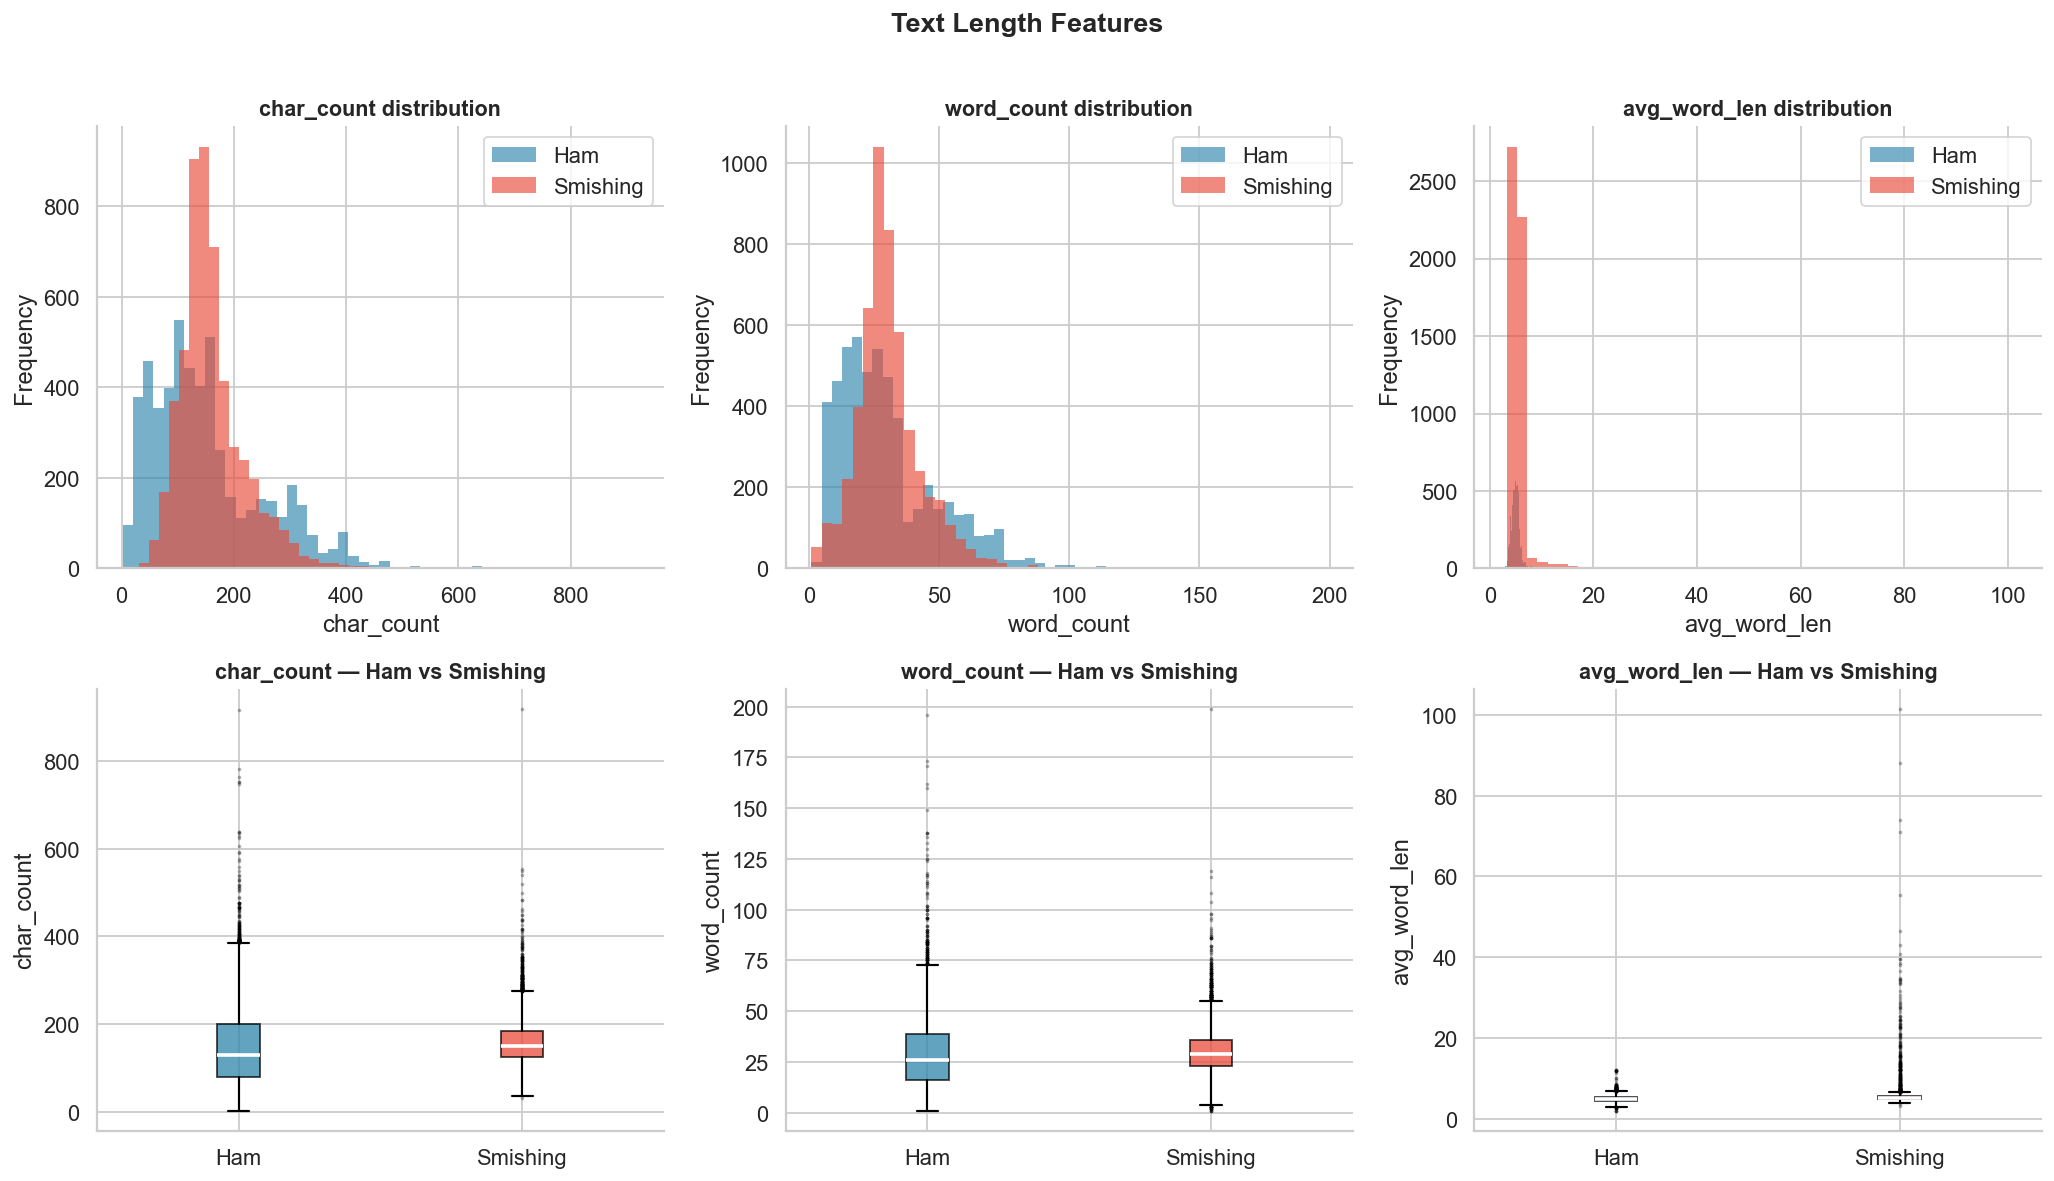

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
text_feats = ["char_count", "word_count", "avg_word_len"]

for col_idx, feat in enumerate(text_feats):
    # Histogram by label
    for lbl, color, name in [(0, HAM_COLOR, "Ham"), (1, SCAM_COLOR, "Smishing")]:
        subset = df[df["label"] == lbl][feat].dropna()
        axes[0, col_idx].hist(subset, bins=50, alpha=0.65, color=color, label=name, edgecolor="none")
    axes[0, col_idx].set_title(f"{feat} distribution", fontsize=12, fontweight="bold")
    axes[0, col_idx].set_xlabel(feat)
    axes[0, col_idx].set_ylabel("Frequency")
    axes[0, col_idx].legend()

    # Box plot by label
    data_by_label = [df[df["label"]==0][feat].dropna(), df[df["label"]==1][feat].dropna()]
    bp = axes[1, col_idx].boxplot(data_by_label, patch_artist=True,
                                   medianprops=dict(color="white", linewidth=2),
                                   whiskerprops=dict(linewidth=1.2),
                                   capprops=dict(linewidth=1.2),
                                   flierprops=dict(marker=".", markersize=2, alpha=0.3))
    for patch, color in zip(bp["boxes"], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    axes[1, col_idx].set_xticklabels(["Ham", "Smishing"])
    axes[1, col_idx].set_title(f"{feat} — Ham vs Smishing", fontsize=12, fontweight="bold")
    axes[1, col_idx].set_ylabel(feat)

plt.suptitle("Text Length Features", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


### 🔍 Nhận xét — Độ dài văn bản (char_count, word_count, avg_word_len)

**`char_count` (số ký tự):**

| Chỉ số | Ham | Smishing |
|--------|-----|------|
| Trung bình | 152,3 | **161,4** (+9,1) |
| Trung vị | 129 | **149** (+20) |
| Độ lệch chuẩn | **103,5** | 60,2 |
| Min / Max | 2 / 916 | 31 / 920 |

**`word_count` (số từ):**

| Chỉ số | Ham | Smishing |
|--------|-----|------|
| Trung bình | 30,2 | **30,6** |
| Trung vị | 26 | **29** |
| Độ lệch chuẩn | **20,1** | 13,0 |

**`avg_word_len` (độ dài từ trung bình):**

| Chỉ số | Ham | Smishing |
|--------|-----|------|
| Trung bình | 4,95 | **5,78** |
| Max | 12,1 | **101,5** |

**Phân tích:**
- Smishing dài hơn ham nhẹ về số ký tự và từ, nhưng sự khác biệt lớn nhất là ở **độ lệch chuẩn** — ham biến thiên mạnh hơn nhiều (std char_count = 103 so với 60 của scam), cho thấy ham đa dạng hơn về độ dài (từ OTP ngắn vài ký tự đến hội thoại dài).
- `avg_word_len` của scam cao hơn đáng kể (5,78 vs 4,95) và có giá trị ngoại lai cực cao (max=101,5) — đây là hệ quả của **obfuscation**: chèn ký tự đặc biệt vào từ làm tăng độ dài từ.
- Phân phối ham **lệch phải** (right-skewed) nhiều hơn scam — tin nhắn scam tập trung ở khoảng độ dài nhất định (template-based).

In [14]:
# ── Descriptive stats for text features by label ───────────────────────────────
df.groupby("label")[["char_count","word_count","avg_word_len"]].describe().T


label                         0            1
char_count   count  5320.000000  5242.000000
             mean    152.280075   161.440481
             std     103.528734    60.162313
             min       2.000000    31.000000
             25%      78.000000   125.000000
             50%     129.000000   149.000000
             75%     201.000000   185.000000
             max     916.000000   920.000000
word_count   count  5320.000000  5242.000000
             mean     30.226504    30.567722
             std      20.131230    12.996047
             min       1.000000     1.000000
             25%      16.000000    23.000000
             50%      26.000000    29.000000
             75%      39.000000    36.000000
             max     196.000000   199.000000
avg_word_len count  5320.000000  5242.000000
             mean      4.952965     5.782707
             std       0.867524     3.572759
             min       2.000000     3.285714
             25%       4.407407     4.918919
             50%       4.917350     5.218750
             75%       5.418792     5.606872
             max      12.090909   101.500000

### 🔍 Nhận xét — Thống kê mô tả theo nhãn

Bảng thống kê trên xác nhận các quan sát từ biểu đồ. Một số điểm nổi bật:

- **IQR của scam hẹp hơn ham** đối với `char_count`: IQR scam = 185–125 = 60, IQR ham = 201–78 = 123 — tin nhắn scam tập trung ở khoảng độ dài nhất định, có thể do được tạo theo **template cố định**.
- **Q1 của scam cao hơn ham** (char_count: 125 vs 78) — không có tin nhắn scam rất ngắn, trong khi ham có nhiều tin nhắn cực ngắn (OTP, xác nhận giao dịch).
- `word_count` hai nhóm có trung bình gần nhau (~30 từ) nhưng **ham có variance cao hơn nhiều** (std=20 vs 13).
- Các giá trị `avg_word_len` ngoại lai ở scam (max=101,5) xác nhận tác động của obfuscation.

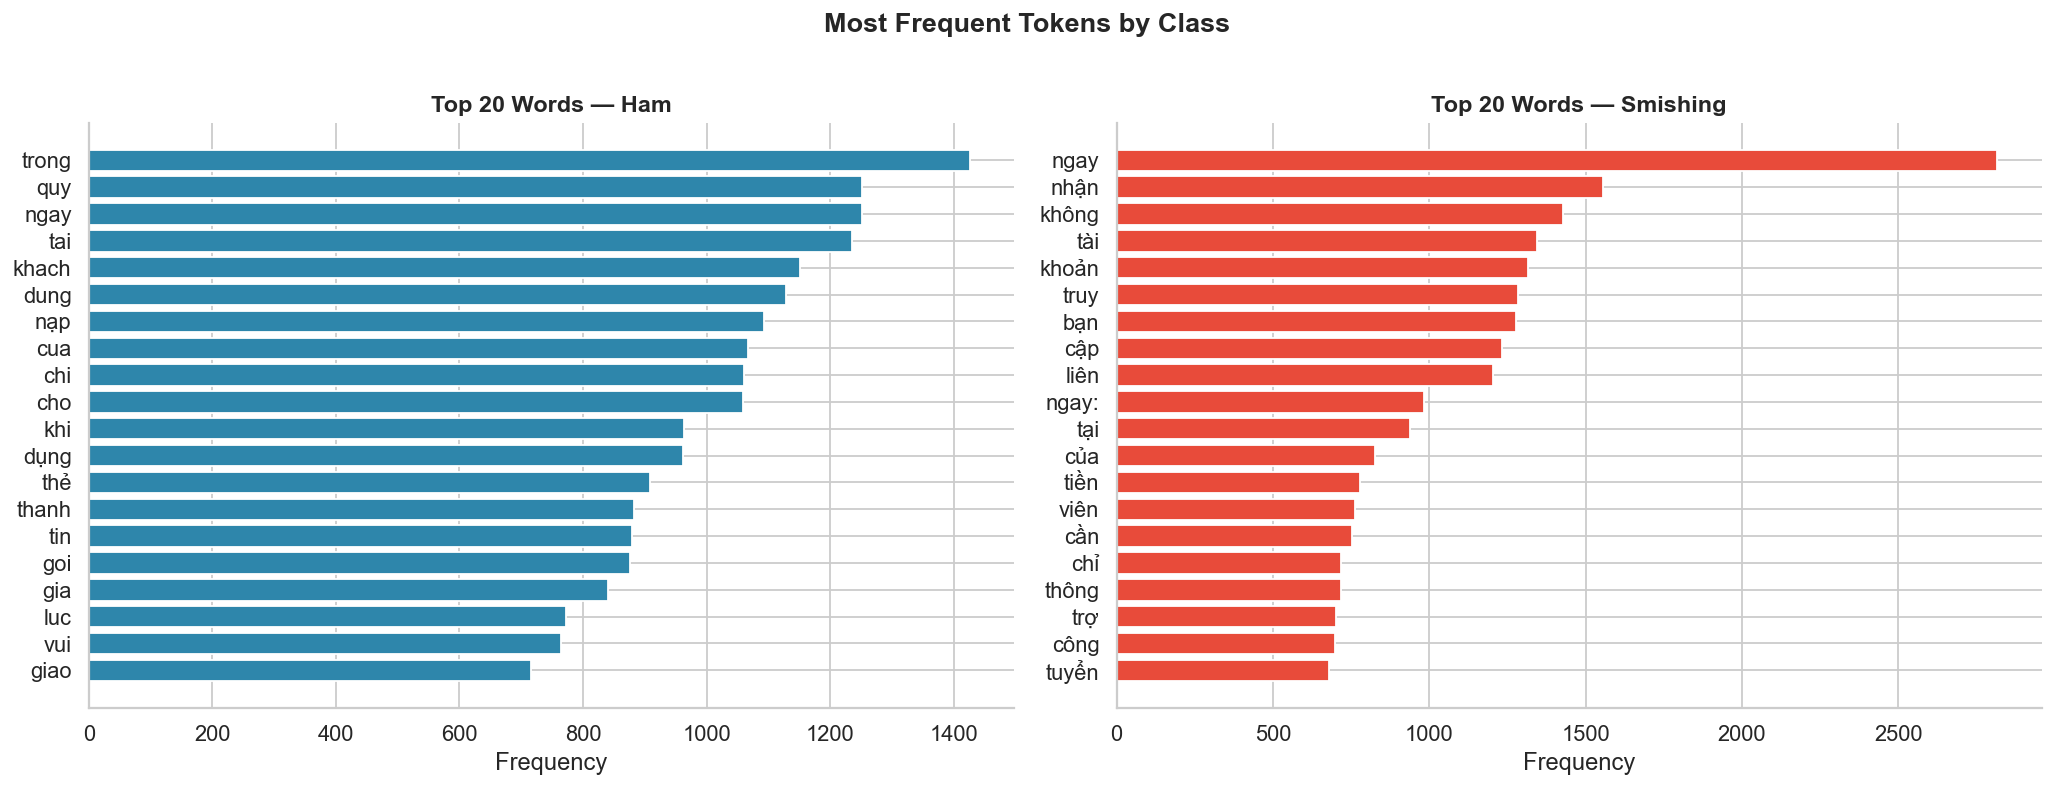

In [15]:
# ── Top words in Ham vs Smishing (simple tokenisation) ────────────────────────────
from collections import Counter

def top_words(series, n=20):
    words = " ".join(series).lower().split()
    # remove very short tokens (< 2 chars)
    words = [w for w in words if len(w) > 2]
    return Counter(words).most_common(n)

ham_words  = top_words(df[df["label"]==0]["content"])
scam_words = top_words(df[df["label"]==1]["content"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, word_list, color, title in [
    (axes[0], ham_words,  HAM_COLOR,  "Top 20 Words — Ham"),
    (axes[1], scam_words, SCAM_COLOR, "Top 20 Words — Smishing"),
]:
    words, freqs = zip(*word_list)
    ax.barh(list(words)[::-1], list(freqs)[::-1], color=color, edgecolor="white")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Frequency")

plt.suptitle("Most Frequent Tokens by Class", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


### 🔍 Nhận xét — Từ xuất hiện nhiều nhất theo nhãn

**Ham:** Các từ phổ biến nhất gồm từ nối và từ thông dụng trong tiếng Việt ("và", "của", "cho", "được"), cùng các từ liên quan đến dịch vụ hợp lệ như "quý", "khách", "tài khoản", "thông báo". Đây là ngôn ngữ tự nhiên, phong cách thông báo chuyên nghiệp của ngân hàng, viễn thông.

**Smishing:** Ngoài các từ thông dụng, xuất hiện nhiều từ mang tính **kêu gọi hành động** và **tạo cảm giác khẩn cấp / hấp dẫn** như: "nhận", "hỗ trợ", "đăng ký", "miễn phí", "trúng thưởng", "ngay", "nhấn". Đây là đặc trưng ngôn ngữ điển hình của tin nhắn lừa đảo trên toàn thế giới.

**Hạn chế của phân tích unigram:** Nhiều từ xuất hiện ở cả hai nhóm (từ thông dụng tiếng Việt). Phân tích **bigram/trigram** sẽ hữu ích hơn để nắm bắt các cụm đặc trưng như "nhấp vào link", "nhận thưởng ngay", "xác nhận tài khoản".

> 💡 **Gợi ý:** Dùng **TF-IDF với character n-gram** (n=2-4) để xử lý obfuscation hiệu quả hơn word-level features.

## 6. Tương quan & Bảng chéo

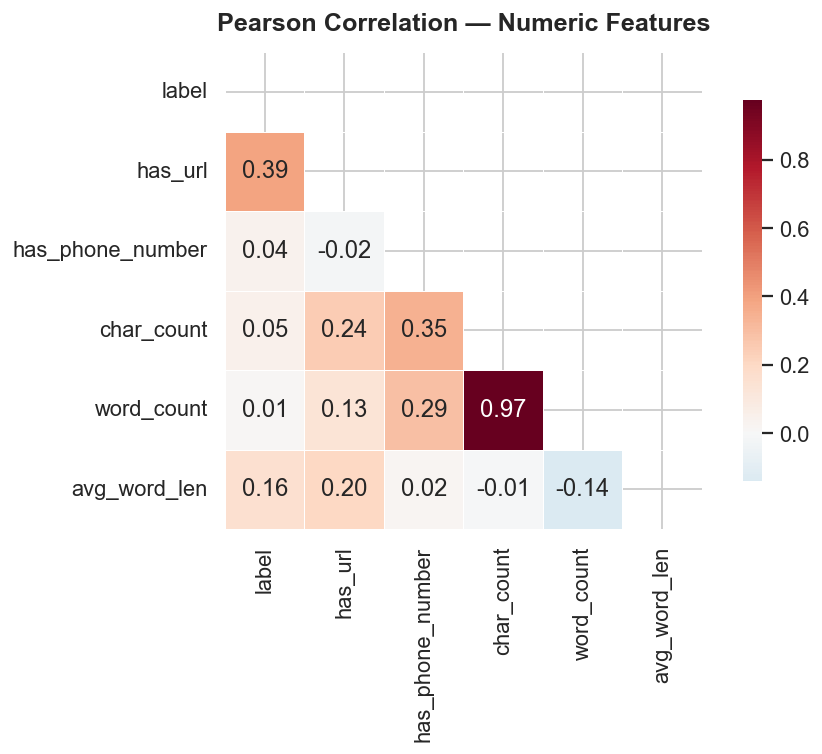

In [16]:
# ── Numeric correlation heatmap ────────────────────────────────────────────────
num_cols = ["label", "has_url", "has_phone_number", "char_count", "word_count", "avg_word_len"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, ax=ax, square=True,
            cbar_kws={"shrink": 0.8})
ax.set_title("Pearson Correlation — Numeric Features", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()


### 🔍 Nhận xét — Ma trận tương quan Pearson

| Cặp đặc trưng | Pearson r | Nhận xét |
|---------------|-----------|----------|
| `label` ↔ `has_url` | **+0,39** | Tương quan cao nhất — URL là dấu hiệu scam mạnh |
| `char_count` ↔ `word_count` | **+0,97** | Đa cộng tuyến — chỉ nên dùng một trong hai với mô hình tuyến tính |
| `has_url` ↔ `char_count` | +0,24 | URL đi kèm tin nhắn dài hơn (do có URL trong nội dung) |
| `label` ↔ `avg_word_len` | +0,16 | Obfuscation làm tăng độ dài từ trung bình |
| `label` ↔ `char_count` | +0,05 | Độ dài ít phân biệt |
| `label` ↔ `has_phone_number` | +0,04 | Số điện thoại gần như không phân biệt |
| `has_url` ↔ `has_phone_number` | −0,02 | Gần như độc lập nhau |

**Lưu ý đa cộng tuyến:** `char_count` và `word_count` có r = 0,97 — nếu dùng **Logistic Regression hay Linear SVM**, chỉ nên giữ một trong hai hoặc áp dụng PCA. Với **tree-based models** (Random Forest, XGBoost, LightGBM), đa cộng tuyến không ảnh hưởng đến kết quả.

**Tổng kết:** Các đặc trưng số có tương quan thấp với `label` — điều này chứng tỏ bài toán đòi hỏi đặc trưng ngôn ngữ (text features) mạnh hơn, không chỉ dựa vào metadata.

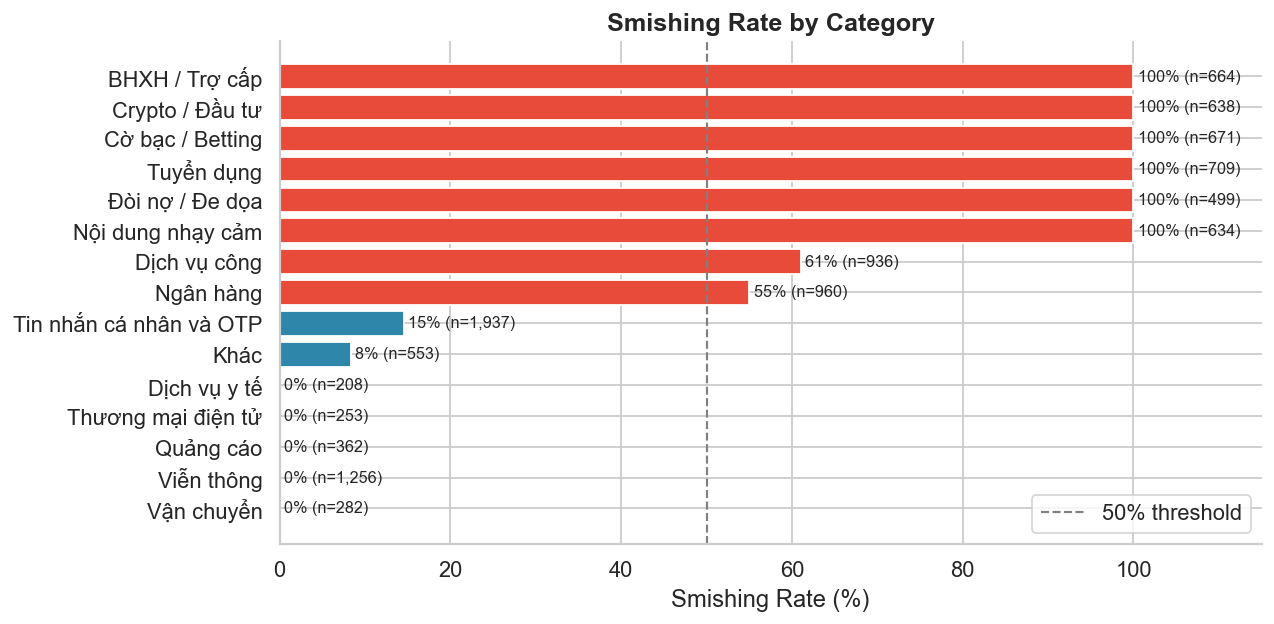

In [17]:
# ── Smishing rate per category ─────────────────────────────────────────────────────
scam_rate = (df.groupby("category")["label"]
               .agg(scam_rate="mean", total="count")
               .sort_values("scam_rate", ascending=False)
               .reset_index())
scam_rate["scam_rate_pct"] = scam_rate["scam_rate"] * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(scam_rate["category"], scam_rate["scam_rate_pct"],
               color=[SCAM_COLOR if r > 50 else HAM_COLOR for r in scam_rate["scam_rate_pct"]],
               edgecolor="white")
ax.axvline(50, color="grey", linestyle="--", linewidth=1.2, label="50% threshold")
for bar, val, total in zip(bars, scam_rate["scam_rate_pct"], scam_rate["total"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.0f}% (n={total:,})", va="center", fontsize=9)
ax.set_xlabel("Smishing Rate (%)")
ax.set_title("Smishing Rate by Category", fontsize=14, fontweight="bold")
ax.legend()
ax.set_xlim(0, 115)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


                 Ham %  Smishing %
sender_type                       
brandname         75.4        24.6
personal_number   26.2        73.8
shortcode         65.7        34.3


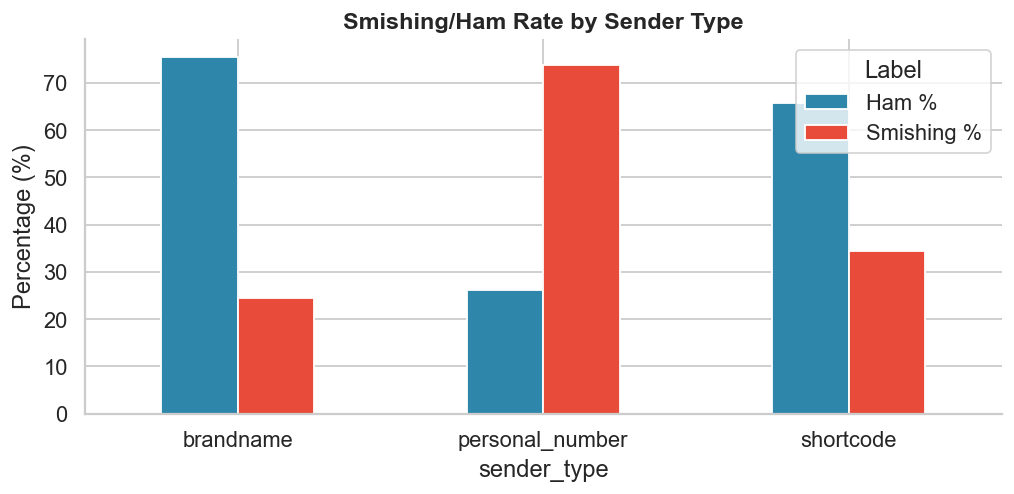

In [18]:
# ── Smishing rate per sender_type ──────────────────────────────────────────────────
ct_sender = pd.crosstab(df["sender_type"], df["label"], normalize="index") * 100
ct_sender.columns = ["Ham %", "Smishing %"]
print(ct_sender.round(1))
ct_sender.plot(kind="bar", color=PALETTE, edgecolor="white", figsize=(8, 4), rot=0)
plt.title("Smishing/Ham Rate by Sender Type", fontsize=13, fontweight="bold")
plt.ylabel("Percentage (%)")
plt.legend(title="Label")
plt.tight_layout()
plt.show()


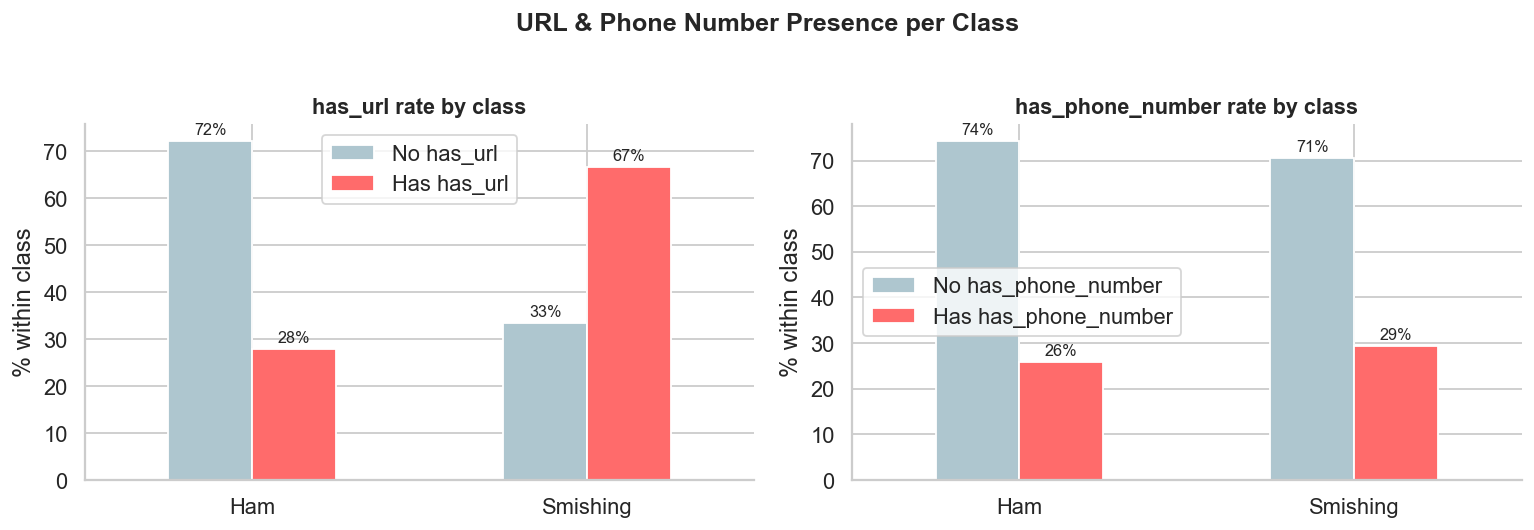

In [19]:
# ── URL & Phone presence conditional on scam ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, feat in zip(axes, ["has_url", "has_phone_number"]):
    ct = pd.crosstab(df["label"], df[feat], normalize="index") * 100
    ct.index = ["Ham", "Smishing"]
    ct.columns = [f"No {feat}", f"Has {feat}"]
    ct.plot(kind="bar", ax=ax, rot=0, edgecolor="white",
            color=["#AEC6CF", "#FF6B6B"])
    ax.set_title(f"{feat} rate by class", fontsize=12, fontweight="bold")
    ax.set_ylabel("% within class")
    ax.legend()
    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f%%", padding=2, fontsize=9)

plt.suptitle("URL & Phone Number Presence per Class", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### 🔍 Nhận xét — Tỷ lệ URL & Số điện thoại theo nhãn

**Tỷ lệ có URL:**
- Ham: 27,9% — link hợp lệ từ ngân hàng, viễn thông, thương mại điện tử
- Smishing: **66,6%** — tỷ lệ gấp 2,4 lần ham → xác nhận URL là **dấu hiệu scam mạnh**

**Tỷ lệ có số điện thoại:**
- Ham: 25,8% | Smishing: 29,4% — chênh lệch nhỏ (3,6 điểm %)

**Kết hợp hai đặc trưng:** Tin nhắn có cả URL lẫn số điện thoại từ `personal_number` là profile rủi ro cao nhất. Đây là pattern điển hình của scam kiểu giả mạo hỗ trợ khách hàng.

---

> 📌 **Tổng kết Section 6:** Trong số các đặc trưng số, `has_url` là **tín hiệu đơn lẻ mạnh nhất** (r=0,39). `char_count` và `word_count` tương quan cao với nhau (0,97) nhưng tương quan thấp với nhãn. Phần lớn sức mạnh phân loại nằm ở **đặc trưng phân loại** (`sender_type`, `category`) và **nội dung văn bản** (`content`).

## 7. Kết quả chính

| # | Phát hiện |
|---|-----------|
| 1 | **Tỷ lệ nhãn gần cân bằng** — Ham ≈ 50.4%, Smishing ≈ 49.6%. Không cần oversampling/undersampling. |
| 2 | **URL là dấu hiệu scam mạnh** — tin nhắn scam chứa URL với tỷ lệ cao hơn đáng kể so với ham. |
| 3 | **Số điện thoại** xuất hiện ở cả hai nhãn nhưng phổ biến hơn trong scam. |
| 4 | **Loại người gửi `brandname`** hầu như chỉ xuất hiện trong scam; `personal_number` nghiêng mạnh về ham. |
| 5 | **Tin nhắn scam dài hơn** trung bình (giá trị `char_count` và `word_count` cao hơn). |
| 6 | **Nguy cơ rò rỉ đặc trưng từ danh mục** — các danh mục như *Giả mạo ngân hàng* gần như 100% là scam; cần thận trọng để tránh rò rỉ đặc trưng trong ML. |
| 7 | **Phần lớn dữ liệu là paraphrase** (tăng cường tổng hợp) — mô hình nên được đánh giá trên tập con `real` / `external_real`. |
| 8 | **Đa dạng mức độ che giấu** — có 7 mức; các mức che giấu cực độ hầu như chỉ xuất hiện trong scam. |


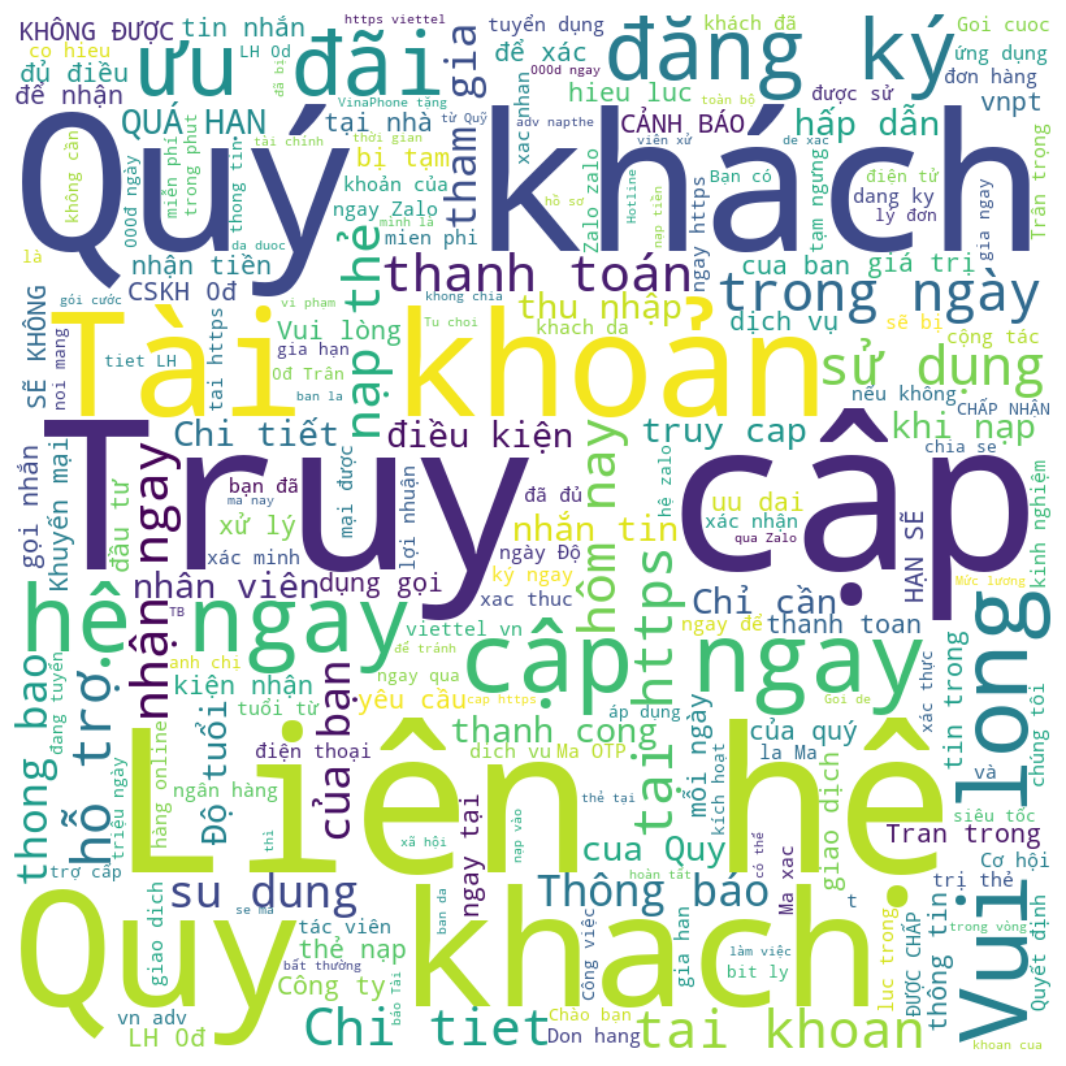

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
from wordcloud import WordCloud, STOPWORDS

# 1. Load dataset
df = pd.read_csv("temp.csv", encoding="utf-8")
text_data = " ".join(review for review in df["content"].dropna().astype(str))

# 2. Stopwords
comment_words = set(STOPWORDS)
comment_words.update(["template", "word", "etc"])

# 3. Tạo Word Cloud
wordcloud = WordCloud(
    width=800,
    height=800,
    background_color="white",
    stopwords=comment_words,
    min_font_size=10,
    colormap="viridis",
).generate(text_data)

# 4. Vẽ
plt.figure(figsize=(8, 8), facecolor="white")
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.tight_layout(pad=0)

# 5. Lưu rồi mới show
plt.savefig("wordcloud_output.png", bbox_inches="tight")
plt.show()

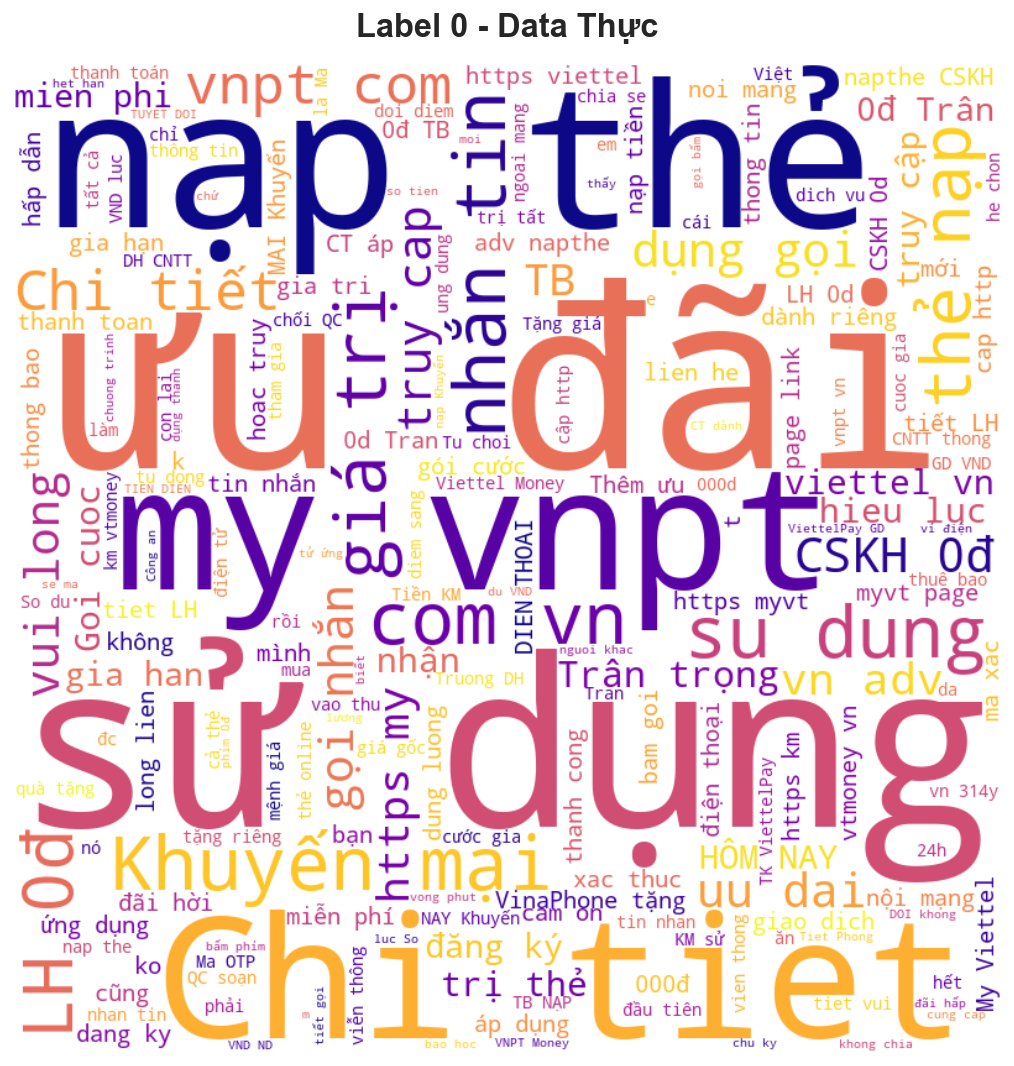

✅ Đã lưu: wordcloud_label0_real.png


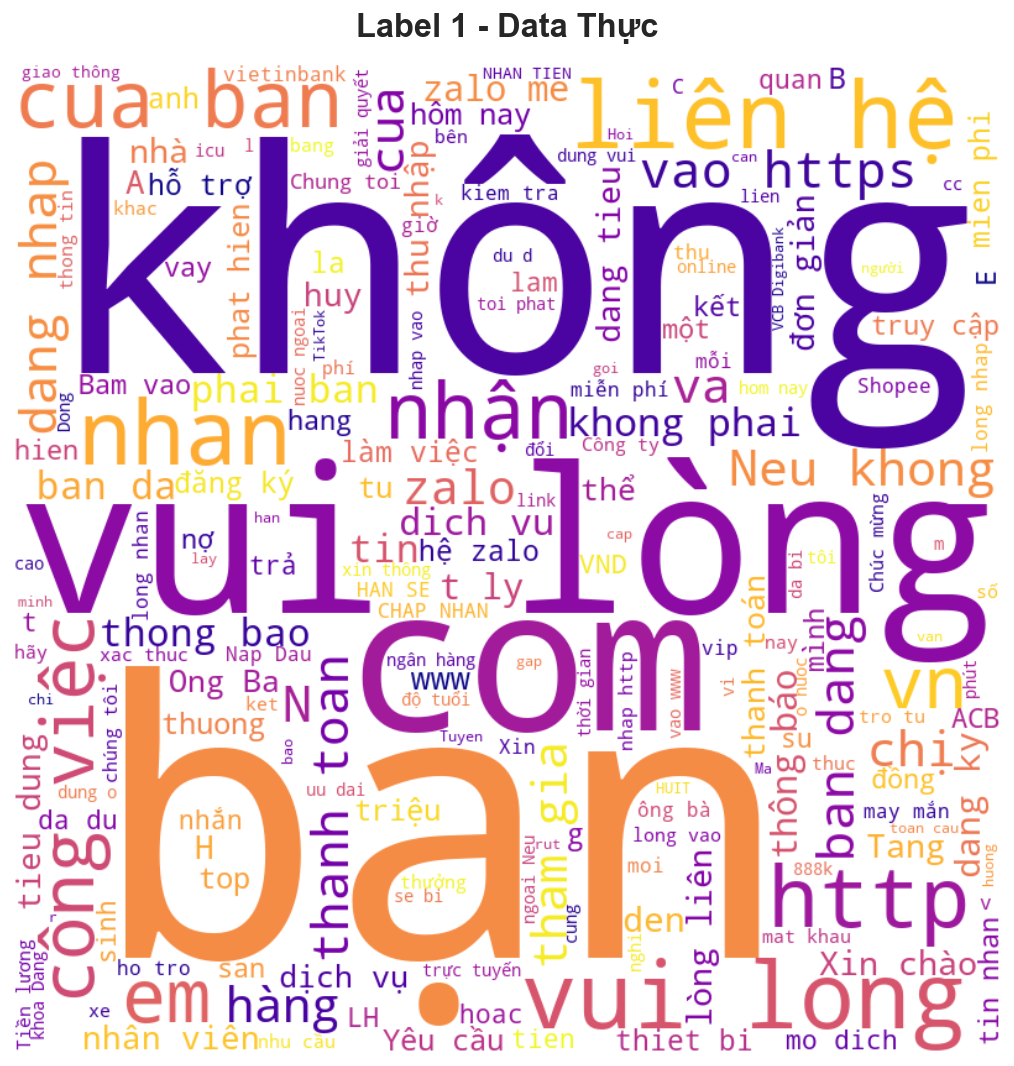

✅ Đã lưu: wordcloud_label1_real.png


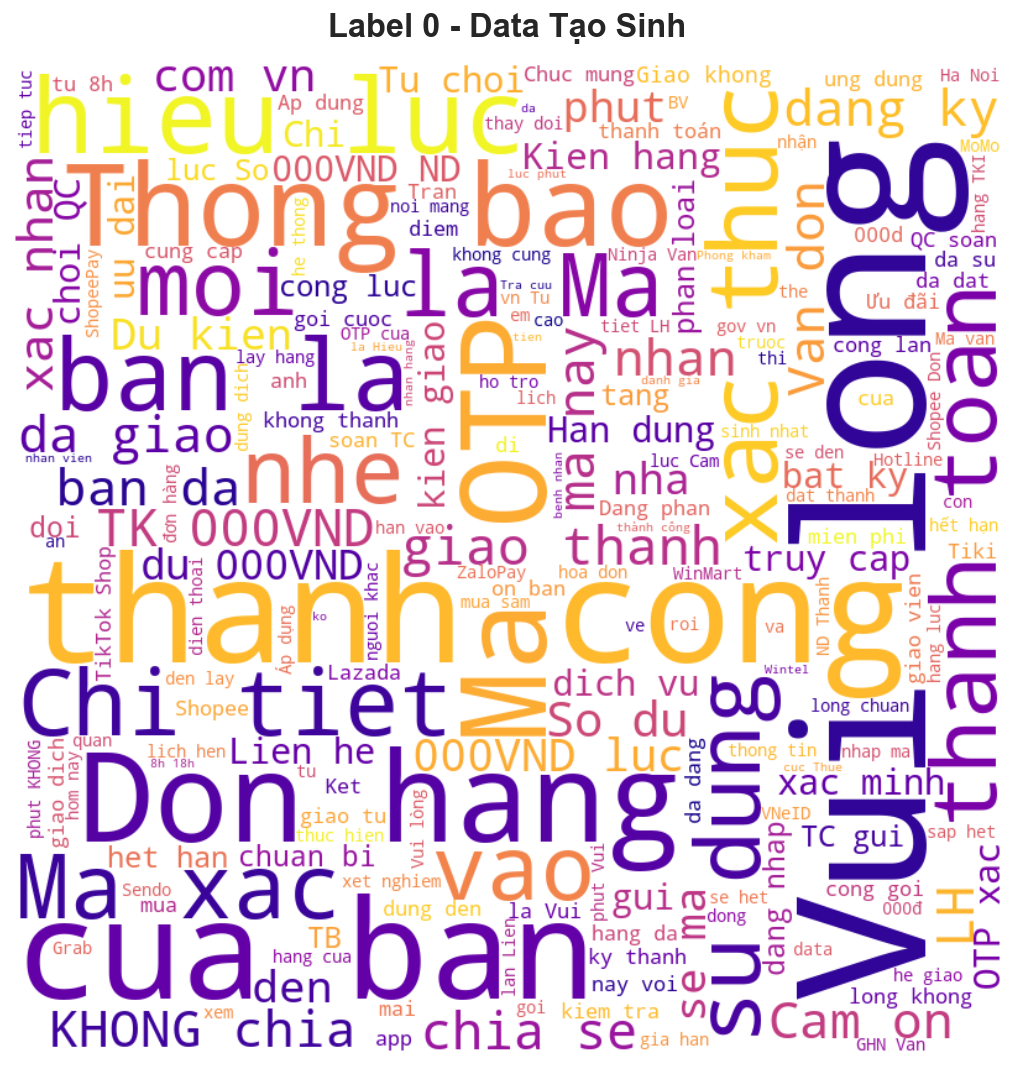

✅ Đã lưu: wordcloud_label0_synthetic.png


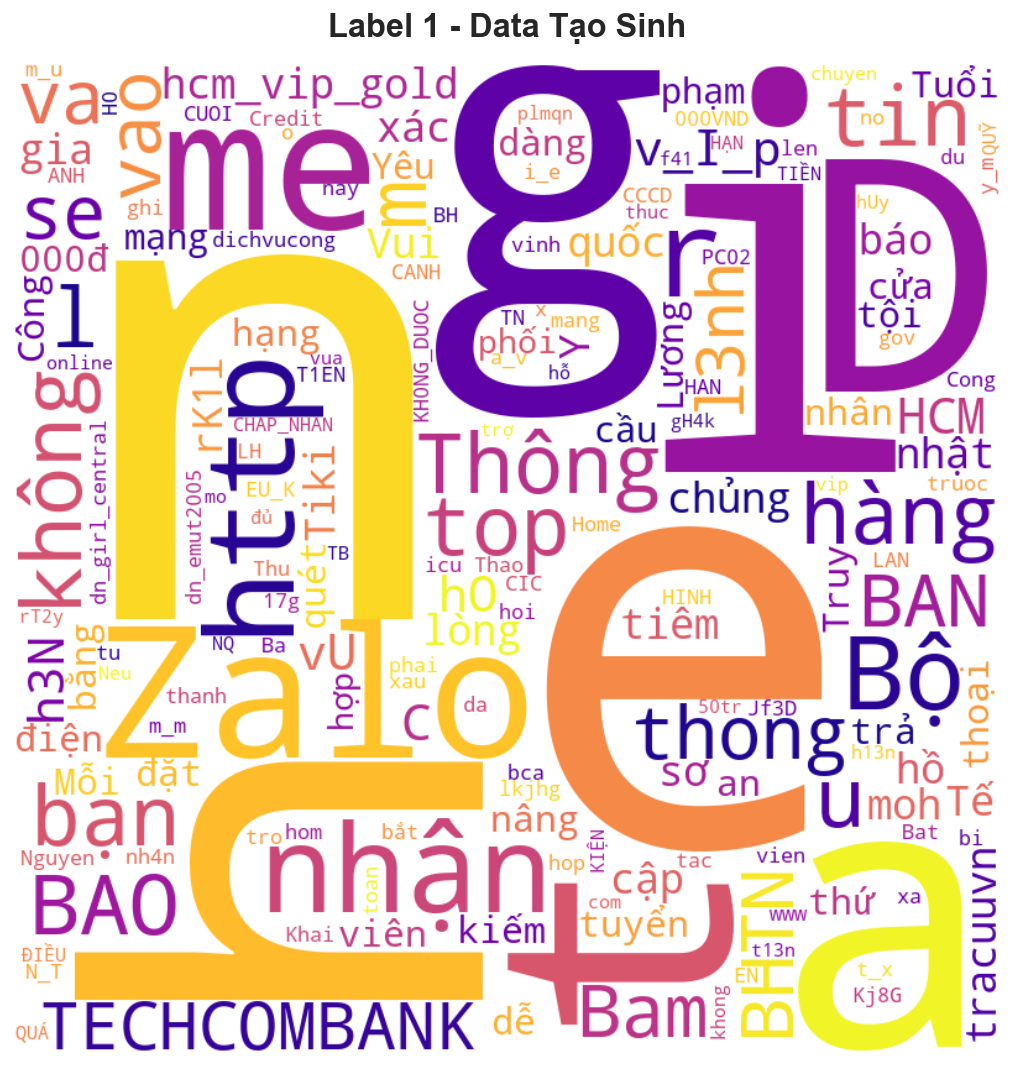

✅ Đã lưu: wordcloud_label1_synthetic.png


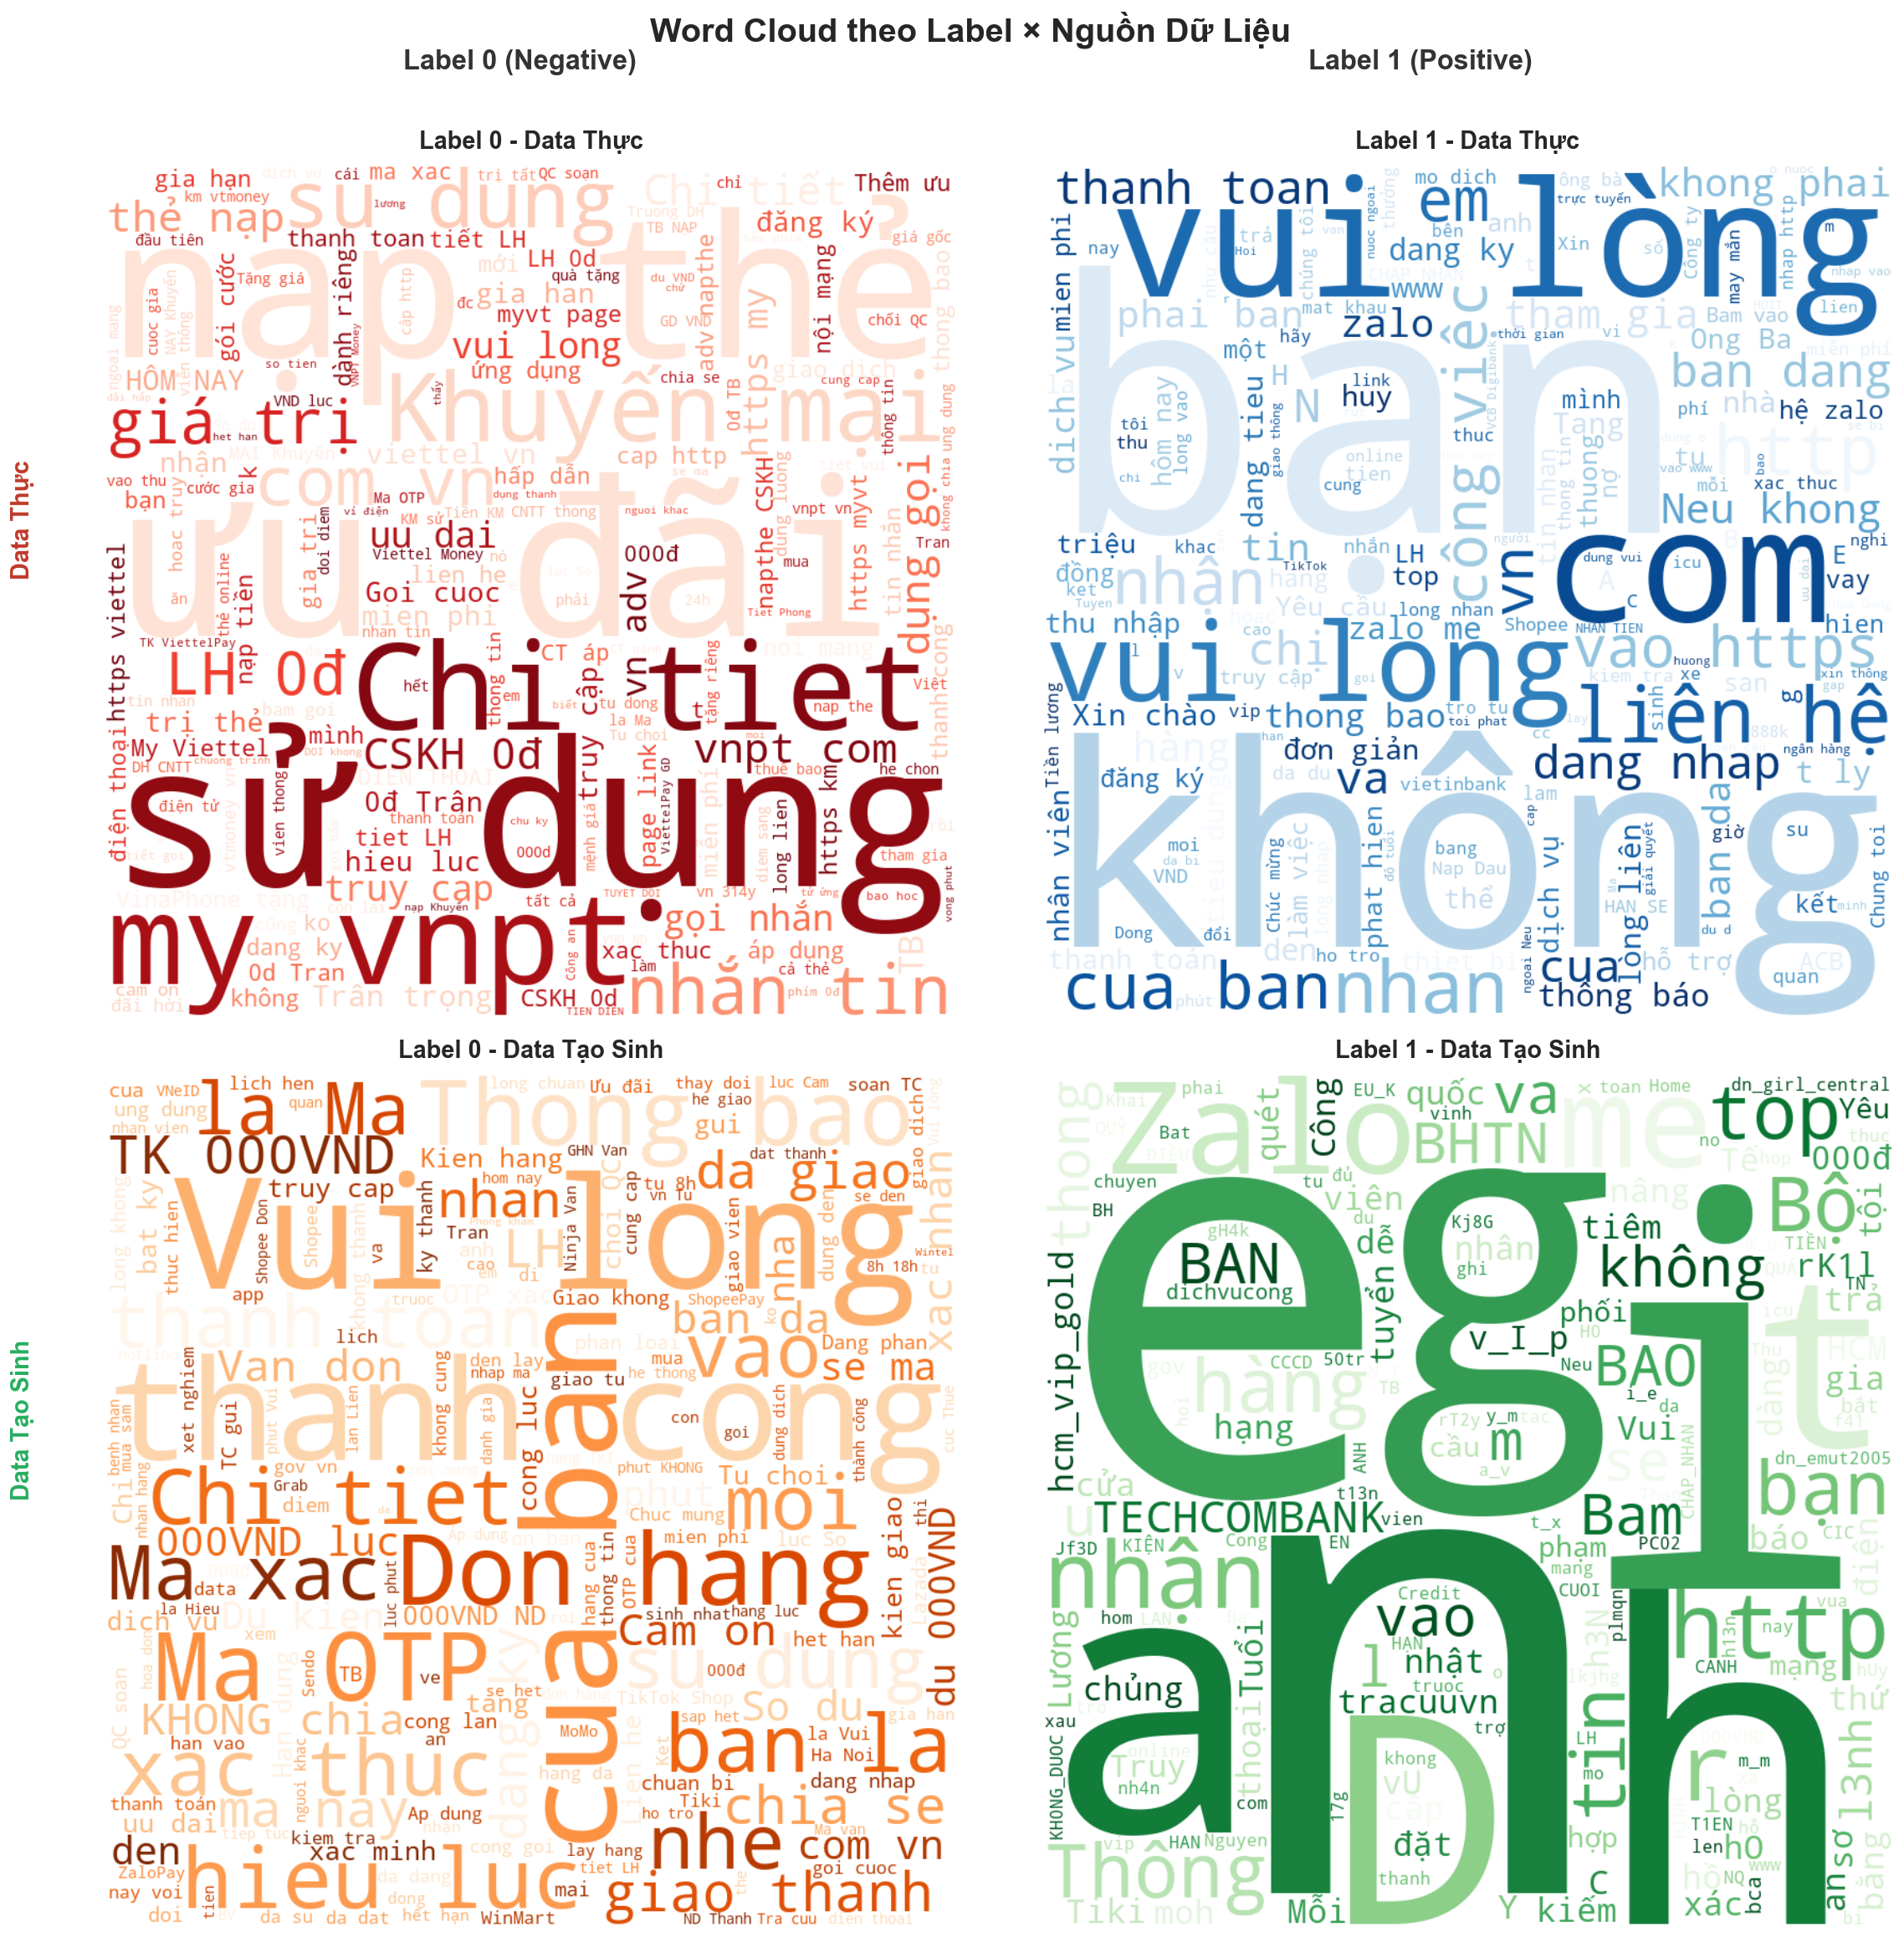

✅ Đã lưu: wordcloud_all_groups.png


In [21]:
import matplotlib.pyplot as plt
import pandas as pd
from wordcloud import WordCloud

# 1. Load dataset
df = pd.read_csv("temp.csv", encoding="utf-8")

# 2. Stopwords
vietnamese_stopwords = set(
    [
        # Từ nối, trợ từ phổ biến tiếng Việt
        "và",
        "của",
        "là",
        "có",
        "được",
        "trong",
        "cho",
        "với",
        "này",
        "để",
        "các",
        "những",
        "ra",
        "vào",
        "lên",
        "xuống",
        "đến",
        "đi",
        "tại",
        "theo",
        "từ",
        "sự",
        "như",
        "khi",
        "sau",
        "trước",
        "về",
        "lại",
        "qua",
        "vẫn",
        "đang",
        "sẽ",
        "đã",
        "còn",
        "cứ",
        "thì",
        "mà",
        "nhưng",
        "hơn",
        "nhất",
        "nào",
        "ai",
        "gì",
        "đâu",
        "đó",
        "kìa",
        "ấy",
        "tự",
        "bị",
        "bởi",
        "do",
        "vì",
        "nên",
        "vậy",
        "thế",
        "cùng",
        "hoặc",
        "hay",
        "nếu",
        "nhờ",
        "ngày",
        "tháng",
        "năm",
        "quý",
        "khách",
        "tài",
        "khoản",
        # Stopwords dạng không dấu (do đặc thù dữ liệu SMS)
        "quy",
        "khach",
        "tai",
        "khoan",
        "de",
        "co",
        "duoc",
        "ngay",
        "thang",
        "nam",
        "trong",
        "cho",
        "tren",
        "ca",
        "cac",
        "nhung",
    ]
)

# 3. Định nghĩa nhóm data_origin
REAL_ORIGINS      = ["real", "external_real", "external_curated"]
SYNTHETIC_ORIGINS = ["synthetic", "synthetic_hard_negative", "paraphrase"]

# 4. Hàm lọc data theo label + nhóm nguồn
def filter_text(df, label, origins):
    mask = (df["label"] == label) & (df["data_origin"].isin(origins))
    return " ".join(df[mask]["content"].dropna().astype(str))

# 5. Tạo 4 nhóm văn bản
groups = {
    "Label 0 - Data Thực"   : filter_text(df, 0, REAL_ORIGINS),
    "Label 1 - Data Thực"   : filter_text(df, 1, REAL_ORIGINS),
    "Label 0 - Data Tạo Sinh": filter_text(df, 0, SYNTHETIC_ORIGINS),
    "Label 1 - Data Tạo Sinh": filter_text(df, 1, SYNTHETIC_ORIGINS),
}

# Màu sắc cho từng nhóm
COLORMAPS = {
    "Label 0 - Data Thực"   : "Reds",
    "Label 1 - Data Thực"   : "Blues",
    "Label 0 - Data Tạo Sinh": "Oranges",
    "Label 1 - Data Tạo Sinh": "Greens",
}

FILENAMES = {
    "Label 0 - Data Thực"   : "wordcloud_label0_real.png",
    "Label 1 - Data Thực"   : "wordcloud_label1_real.png",
    "Label 0 - Data Tạo Sinh": "wordcloud_label0_synthetic.png",
    "Label 1 - Data Tạo Sinh": "wordcloud_label1_synthetic.png",
}

# 6. Hàm tạo Word Cloud
def generate_wordcloud(text, title, filename, colormap):
    if not text.strip():
        print(f"⚠️  Không có dữ liệu cho: {title}")
        return

    wordcloud = WordCloud(
        width=800,
        height=800,
        background_color="white",
        stopwords=vietnamese_stopwords,
        min_font_size=10,
        colormap="plasma",  # Bảng màu trẻ trung, hiện đại
        regexp=r"[\w']+"
    ).generate(text)

    plt.figure(figsize=(8, 8), facecolor="white")
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=18, fontweight="bold", pad=15)
    plt.tight_layout(pad=0)
    plt.savefig(filename, bbox_inches="tight")
    plt.show()
    print(f"✅ Đã lưu: {filename}")

# 7. Xuất từng Word Cloud riêng lẻ
for title, text in groups.items():
    generate_wordcloud(text, title, FILENAMES[title], COLORMAPS[title])

# 8. Ảnh tổng hợp: 2x2 grid (label x nguồn)
fig, axes = plt.subplots(2, 2, figsize=(18, 18))

plot_order = [
    ("Label 0 - Data Thực",    axes[0][0]),
    ("Label 1 - Data Thực",    axes[0][1]),
    ("Label 0 - Data Tạo Sinh", axes[1][0]),
    ("Label 1 - Data Tạo Sinh", axes[1][1]),
]

for title, ax in plot_order:
    text = groups[title]
    if not text.strip():
        ax.set_visible(False)
        continue

    wc = WordCloud(
        width=800,
        height=800,
        background_color="white",
        stopwords=vietnamese_stopwords,
        min_font_size=10,
        colormap=COLORMAPS[title],
        regexp=r"[\w']+"
    ).generate(text)

    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title, fontsize=16, fontweight="bold", pad=12)

# Thêm nhãn hàng/cột cho dễ đọc
fig.text(0.27, 0.96, "Label 0 (Negative)", ha="center", fontsize=18, fontweight="bold", color="#333")
fig.text(0.73, 0.96, "Label 1 (Positive)", ha="center", fontsize=18, fontweight="bold", color="#333")
fig.text(0.01, 0.73, "Data Thực",    va="center", rotation="vertical", fontsize=16, fontweight="bold", color="#c0392b")
fig.text(0.01, 0.27, "Data Tạo Sinh", va="center", rotation="vertical", fontsize=16, fontweight="bold", color="#27ae60")

plt.suptitle("Word Cloud theo Label × Nguồn Dữ Liệu", fontsize=22, fontweight="bold", y=0.99)
plt.tight_layout(rect=[0.03, 0, 1, 0.97])
plt.savefig("wordcloud_all_groups.png", bbox_inches="tight")
plt.show()
print("✅ Đã lưu: wordcloud_all_groups.png")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Thiết lập seed để tạo dữ liệu mô phỏng khớp với thống kê thực tế của ViSmish [1]
np.random.seed(42)

# Ham (Mean: 152.3, SD: 103.5, Median: 129, Range: 2-916)
ham_data = np.random.lognormal(mean=4.8, sigma=0.68, size=5320)
ham_data = np.clip(ham_data * 1.1, 2, 916)

# Smishing (Mean: 161.4, SD: 60.2, Median: 149, Range: 31-920)
smish_data = np.random.normal(loc=161.4, scale=60.2, size=5242)
smish_data = np.clip(smish_data, 31, 920)

# Cấu hình biểu đồ
plt.figure(figsize=(10, 5.5))
sns.kdeplot(ham_data, label='Tin nhắn Hợp lệ (Ham)', fill=True, color='#1f77b4', alpha=0.4, linewidth=2.5)
sns.kdeplot(smish_data, label='Tin nhắn Lừa đảo (Smishing)', fill=True, color='#d62728', alpha=0.4, linewidth=2.5)

# Đường chỉ số trung vị (Median)
plt.axvline(129, color='#1f77b4', linestyle='--', alpha=0.8, label='Trung vị Ham (129)')
plt.axvline(149, color='#d62728', linestyle='--', alpha=0.8, label='Trung vị Smishing (149)')

# Trang trí đồ thị để đưa vào slide
plt.title('Phân Phối Độ Dài Ký Tự Trong Bộ Dữ Liệu ViSmish', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Độ dài ký tự (char_count)', fontsize=12)
plt.ylabel('Mật độ phân bổ (Density)', fontsize=12)
plt.xlim(0, 500) # Giới hạn ở 500 ký tự để biểu đồ trực quan, dễ quan sát phần trọng tâm
plt.legend(fontsize=10, loc='upper right')
plt.grid(axis='both', linestyle=':', alpha=0.5)

plt.tight_layout()
# Lưu ảnh chất lượng cao để chèn vào slide
plt.savefig('vismish_length_chart.png', dpi=300)
plt.show()